### Case II : Restriction 35% of Natural Gas flow and the electricity from the grid is 100% renewable

#### Importing Libraries

In [1]:
import os
import oemof.thermal.compression_heatpumps_and_chillers as cmpr_hp_chiller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from oemof import solph
from oemof.tools import economics
from oemof.solph import processing, views
from oemof.solph import EnergySystem, Flow, Model, constraints

#### 1) Importing data

#### 1.1 Reading input data: thermal and electric profiles

In [2]:
profiles_file = os.path.join('exam_project_profiles.csv')
date_format = '%Y-%m-%d %H:%M:%S'

# Use errors='coerce' to handle parsing errors
date_parser = lambda x: pd.to_datetime(x, format=date_format, errors='coerce')

# Read the CSV file with the specified date_parser
input_profiles = pd.read_csv(profiles_file, parse_dates=True, date_parser=date_parser, index_col='timestamp')

# If you want to create a new timestamp column:
start_time = '2021-01-01 00:00:00'
end_time = '2021-12-31 23:00:00'
time_step = pd.to_timedelta('1 hour')
input_profiles['timestamp'] = pd.date_range(start=start_time, end=end_time, freq=time_step)

#Set the newly created timestamp column as the index
input_profiles.set_index('timestamp', inplace=True)

#Drop NaN values in the DataFrame
input_profiles.dropna(inplace=True)

In [3]:
input_profiles

,Pel kW,Pth kW
timestamp,,
2021-01-01 00:00:00,0.289583,0.398678
2021-01-01 01:00:00,0.285012,0.393958
2021-01-01 02:00:00,0.271620,0.383260
2021-01-01 03:00:00,0.278819,0.394840
2021-01-01 04:00:00,0.267483,0.388232
...,...,...
2021-12-31 19:00:00,0.438614,0.373946
2021-12-31 20:00:00,0.373206,0.388043
2021-12-31 21:00:00,0.327886,0.367212


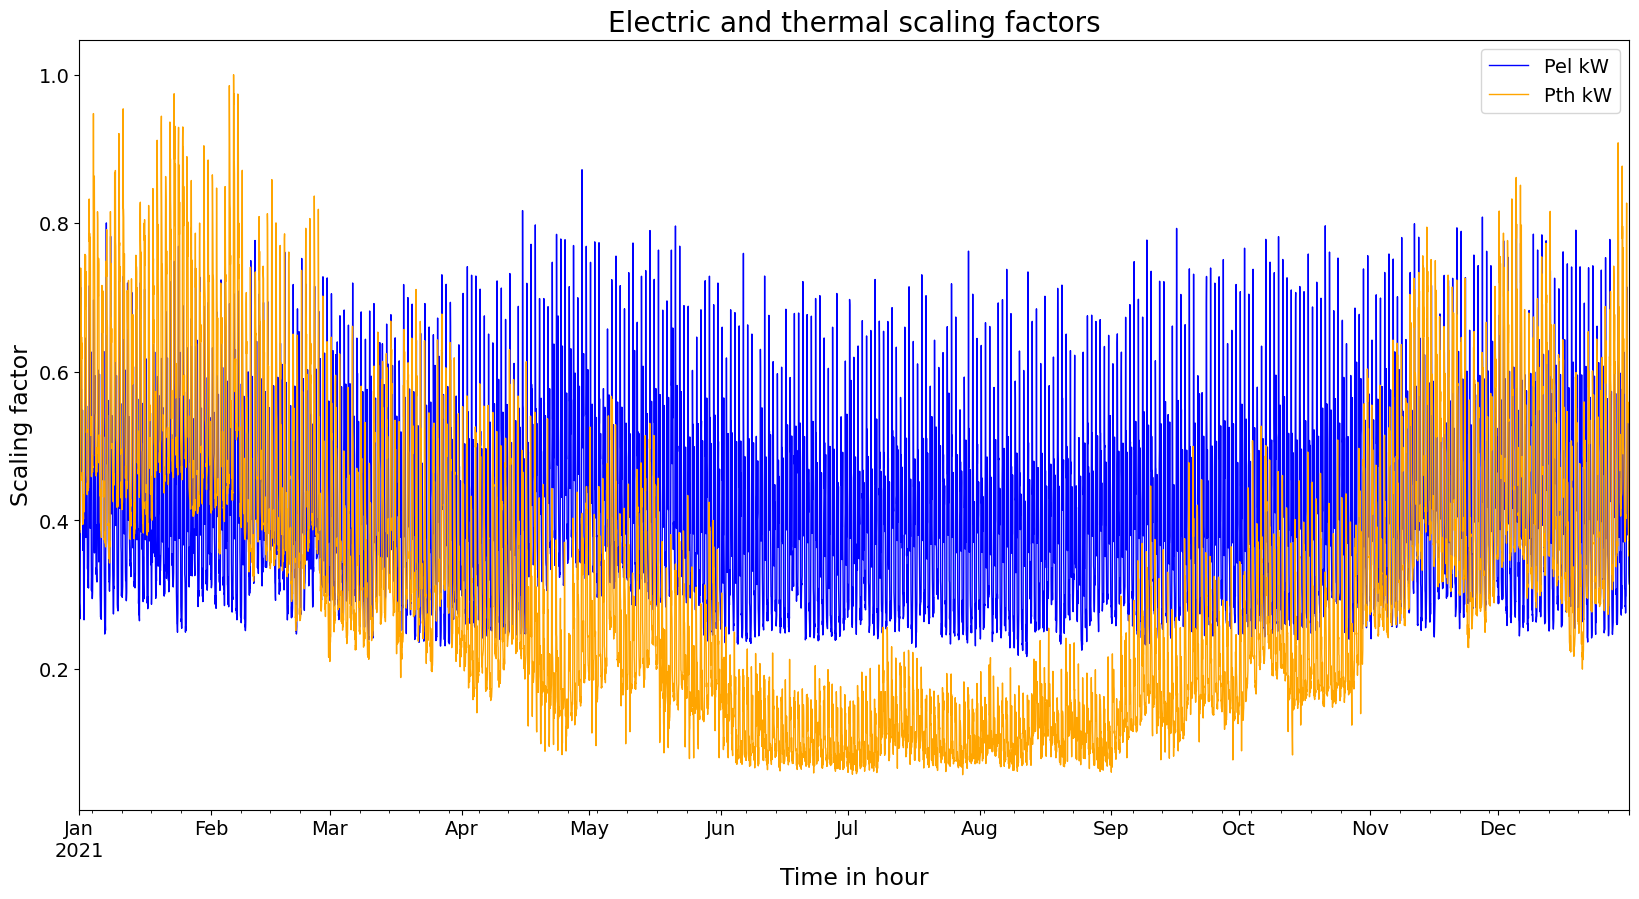

In [4]:
fig, ax = plt.subplots(figsize=(20,10))
input_profiles[['Pel kW', 'Pth kW']].plot(ax=ax, label=['Pel kW', 'Pth kW'], linewidth=1, color=['blue', 'orange'])
ax.set_title('Electric and thermal scaling factors', fontsize=20)
ax.set_xlabel('Time in hour', fontsize=17)
ax.set_ylabel('Scaling factor', fontsize=17)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)

#### 1.2 Reading input data: solar PV generation and temperature

In [5]:
pv_temp_file = os.path.join('SolarPV_gen5.csv')
date_format = '%Y-%m-%d %H:%M:%S'

# Use errors='coerce' to handle parsing errors
date_parserpvt = lambda x: pd.to_datetime(x, format=date_format, errors='coerce')

# Read only the 'P' and 'T2m' columns from the CSV file with the specified date_parser
columns_to_read = ['time', 'P', 'T2m']
input_pvt = pd.read_csv(pv_temp_file, parse_dates=True, date_parser=date_parserpvt, usecols=columns_to_read)

# If you want to create a new timestamp column:
start_timepvt = '2021-01-01 00:00:00'
end_timepvt = '2021-12-31 23:00:00'
time_steppvt = pd.to_timedelta('1 hour')
input_pvt['time'] = pd.date_range(start=start_timepvt, end=end_timepvt, freq=time_steppvt)

# Set the newly created timestamp column as the index
input_pvt.set_index('time', inplace=True)

# Drop NaN values in the DataFrame
input_pvt.dropna(inplace=True)

In [6]:
input_pvt

,P,T2m
time,,
2021-01-01 00:00:00,0.0,4.52
2021-01-01 01:00:00,0.0,4.51
2021-01-01 02:00:00,0.0,4.50
2021-01-01 03:00:00,0.0,4.42
2021-01-01 04:00:00,0.0,4.27
...,...,...
2021-12-31 19:00:00,0.0,-0.42
2021-12-31 20:00:00,0.0,-1.11
2021-12-31 21:00:00,0.0,-1.85


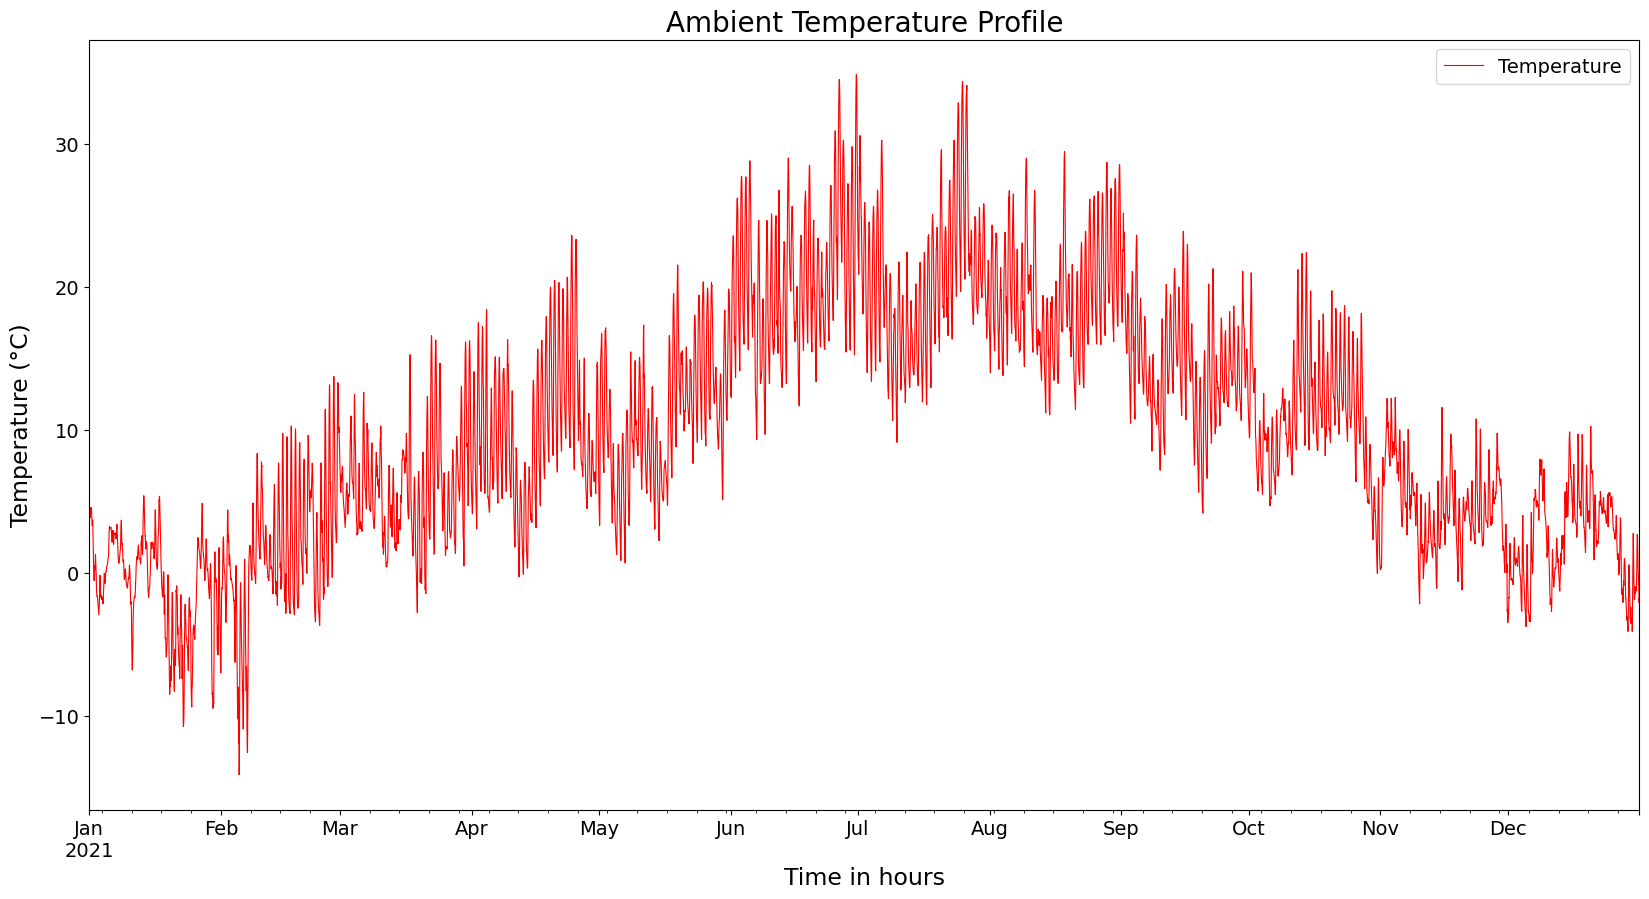

In [7]:
plt.figure(figsize=(20,10))
input_pvt['T2m'].plot(label='Temperature', color='red', linewidth=0.8)
plt.title('Ambient Temperature Profile', fontsize=20)
plt.xlabel('Time in hours', fontsize=17)
plt.ylabel('Temperature (°C)', fontsize=17)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 2)  Defining boundary conditions

In [8]:
# Peak loads
peak_thload = 2500            # Scaling factor for heat load profile in kW
peak_elload = 850             # Scaling factor for electric load profile in kW

#converters features
## Boiler
pow_boiler = 200              # Thermal power output of boiler in kWth (VITOCROSSAL 200 Type CM2: TF/TR = 80/60 °C)
eff_boiler = 0.95             # Efficiency of boiler (VITOCROSSAL 200 Type CM2: TF/TR = 80/60 °C, up to 95%)

## Heat pum
pow_elhp = 368    #409        # Electrical power output of heat pump in kW (GEA heat pump:2x V600 HP: inlet/outlet:35/65 °C)
COP_hp = 8.59                 # COP of the heat pump (GEA heat pump:2x V600 HP: 8.59)

## CHP unit
pow_elchp = 414               # Electric power output of CHP in kWel (PowerBloc EG-530: Electrical output 317 - 532 kWel)
pow_thchp = 530               # thermal power output of CHP in kWth (PowerBloc EG-530: Thermal output 418 - 665 kWth) 
eff_elchp = 0.396             # electric efficiency of CHP in % (PowerBloc EG-530: full load 39.6%) 
eff_thchp = 0.496             # thermal efficiency of CHP in % (PowerBloc EG-530: full load 49.6%) 

## Solar PV power plant
pow_solarpv = 500             # Solar PV power plant capacity in kW
eff_solarpv = 1               # Efficiency solar PV system in kW

## Storage devices
# Thermal storage
cap_th_store = 55109.394      # capacity of thermal storage in kWh

# electric storage
cap_elstore =     172         # Charging power battery in kW
discharge_power = 103         # Discharging power in kW
batt_store_cap =  800         # Battery capacity in kWh
batt_init_level = 0.5         # Initial state of charge of battery

# Energy prices 
#Gas
ng_price = 8                  # Natural gas price in Ct/kWh
BCH4_price = 15               # Biomethane 15 price in Ct/kWh
#Electricity
el_lc_price = 36              # Large consumer electricity price including grid fees in Ct/kWh
el_pc_price = 32              # Private consumer electricity price including grid fees in Ct/kWh

#CO2 Emissions
ffCO2_el= 560                 #CO2 Equivalent in g/kWh of Public Grid
fCO2_ngas= 240                #CO2 Equivalent in g/kWh of Natural Gas
fCO2_BioCH4= 140              #CO2 Equivalent in g/kWh of Biomethane
fpnren_el =1.8                #CO2 Equivalent Factor in g/kWh of Public Grid
fpnren_ngas=1.1               #CO2 Equivalent Factor in g/kWh of Natural Gas
fpnren_bioCH4=0.5             #CO2 Equivalent Factor in g/kWh of Biomethane
fprnren_green= 0
fCO2_green=0
# Revenues for selling electricity to the grid
rev_solarpv = -10             # Revenue from selling electricity to the grid from a solar PV system in Ct/kWh

# Investment cost
gboiler_cost = 150            # Gas boiler costs in €/kWth
gchp_cost = 750               # Gas fired CHP unit cost in €/kWel  
hp_cost = 1500                # Heat pump (large) cost in  €/kWel
solarpv_cost = 750            # Solar power plant cost in  €/kWp 500kW
bos_cost = 0.3*solarpv_cost   # Solar power plant balance of system cost 30% of the total investment cost
th_store_cost= 3              # Investment costs Thermal Storage in €/kwh
el_storage_cost= 132          #Investment of Electrical battery storage in €/kwh

#### 2.1 Definig natural gas constraint: reduction until 35% flow

In [9]:
gas_limit = 8153515*0.35 # limit for gas consumption in kWh

#### 2.2 Defining investment CAPEX

In [10]:
# specific investment for heat pump in €/kW based on electric power of the heat pump
epc_hp = economics.annuity(capex=hp_cost, n=15, wacc=0.05)
# specific investment for boiler in €/kW based on thermal power of the boiler
epc_boiler = economics.annuity(capex=gboiler_cost, n=15, wacc=0.05)
# specific investment for CHP in €/kWe based on thermal power of the boiler
epc_chpe = economics.annuity(capex=gchp_cost, n=15, wacc=0.05)
# specific investment for solar PV power plant in €/kWe based on thermal power of the boiler
epc_solarpv = economics.annuity(capex=solarpv_cost + bos_cost, n=15, wacc=0.05)
# specific investment for Thermal storage (Values can be changed according to the graph provided by prof-CAPEX IN €/kWh)
epc_th_storage = economics.annuity(capex=th_store_cost, n=15, wacc=0.05)


#### 3) Defining energy system model with buses and components

#### 3.1 Defining the energy system and assigning time basis

In [11]:
es_inv_con = solph.EnergySystem(timeindex=input_profiles.index,
                         infer_last_interval=False)

#### 3.2 Defining buses

In [12]:
bus_mix = solph.Bus(label='bus_mix')            # mix of biomethane and natural gas bus
bus_pv = solph.Bus(label='bus_pv')              # solar pv energy generated bus
bus_el = solph.Bus(label='bus_el')              # electricity bus
bus_th = solph.Bus(label='bus_th')              # thermal bus
#bus_bioch4 = solph.Bus(label='bus_bioch4')      # Biomethane bus
bus_gridfeed = solph.Bus(label='bus_gridfeed')  # Electricity from the solap PV power plant that can be sent to public 
                                                # grid of to bus el 

#### 3.3 Defining sources and sinks

In [13]:
## Sources
# source natural gas supply from public gas grid
flow_ngas = solph.flows.Flow(variable_costs=ng_price/100,
                             custom_attributes={'gas_limit':1})

# Source natural gas supply from public natural gas pipeline
supply_ng = solph.components.Source(label='supply_ng',
                                   outputs={bus_mix: flow_ngas})


# Source electricity supply from public grid
supply_el = solph.components.Source(label='supply_el',
                                   outputs={bus_el: solph.Flow(variable_costs=el_lc_price/100)})

# Source solar PV electricity
supply_elspv = solph.components.Source(label='supply_elspv',
                                   outputs={bus_pv: solph.Flow(fix=input_pvt['P']/1000,
                                                               nominal_value=1)})

# Source biomethane supply 
supply_bioch4 = solph.components.Source(label='supply_bioch4',
                                   outputs={bus_mix: solph.Flow(variable_costs=BCH4_price/100)})


## Sinks

# Sink heat load
demand_th = solph.components.Sink(label='demand_th',
                                 inputs={bus_th: solph.Flow(fix=input_profiles['Pth kW'],
                                                           nominal_value=peak_thload)})

# Sink electricity load
demand_el = solph.components.Sink(label='demand_el',
                                 inputs={bus_el: solph.Flow(fix=input_profiles['Pel kW'],
                                                           nominal_value=peak_elload)})

# Sink public electricity grid
pgrid_el = solph.components.Sink(label='pgrid_el',
                                 inputs={bus_gridfeed: solph.Flow(variable_costs=rev_solarpv/100)})

#### 4) Calculate COP for the heat pump

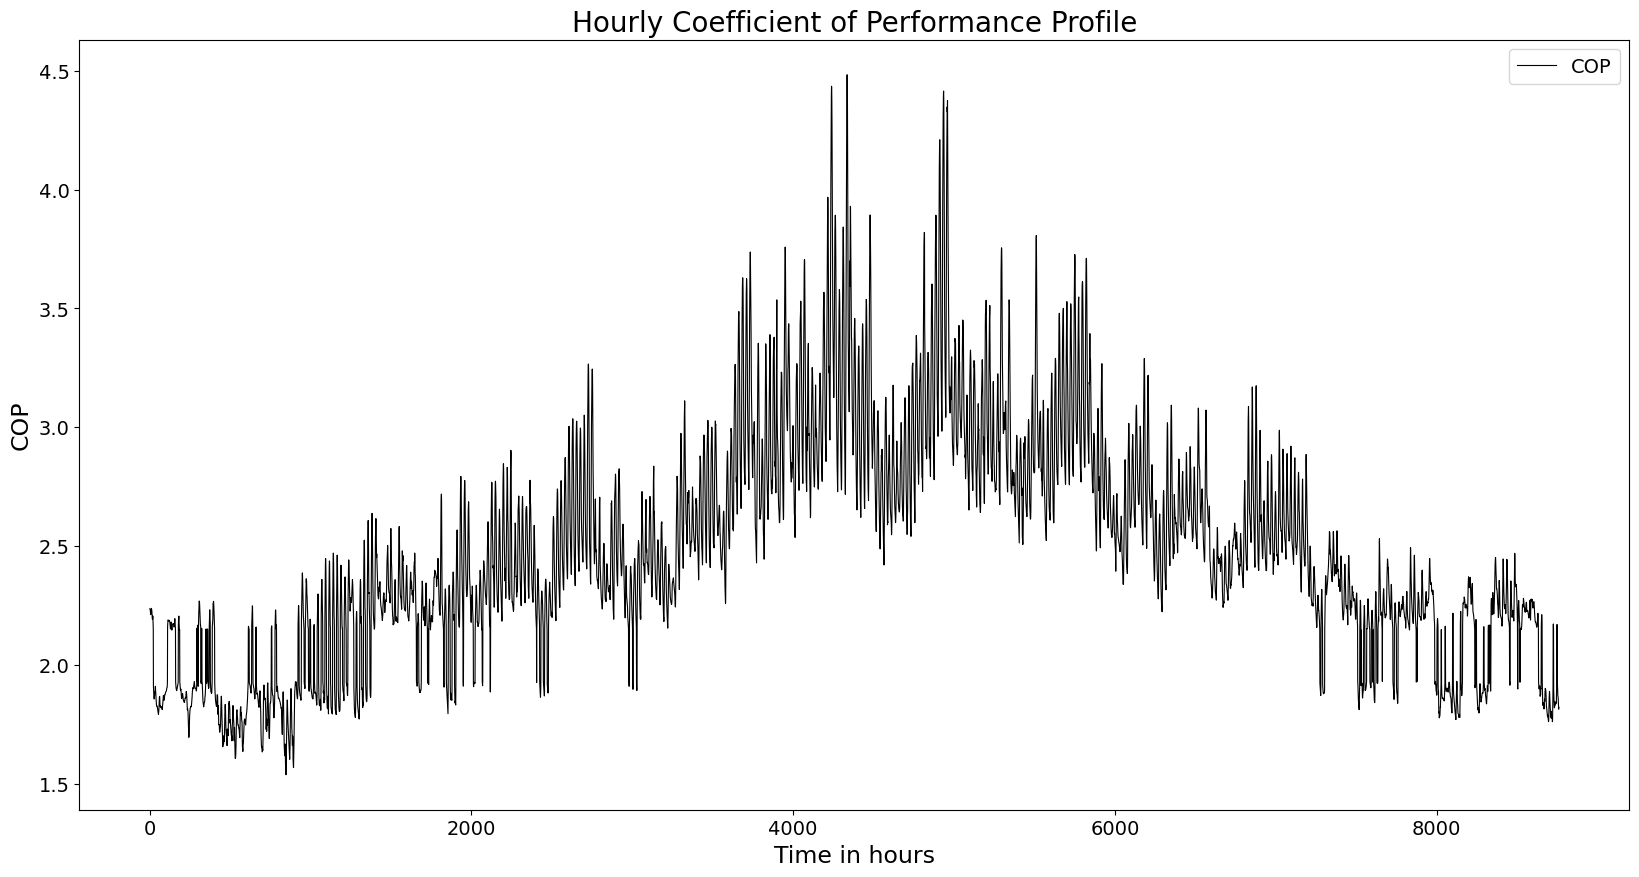

In [14]:
temp_threshold_icing = 2
cops_ASHP = cmpr_hp_chiller.calc_cops(
    temp_high= [65],
    temp_low=input_pvt['T2m'],
    quality_grade=0.4,
    mode='heat_pump',
    temp_threshold_icing=temp_threshold_icing,
    factor_icing=0.9)

plt.figure(figsize=(20, 10))
plt.plot(cops_ASHP, label='COP', color='black', linewidth=0.8)
plt.title('Hourly Coefficient of Performance Profile', fontsize=20)
plt.xlabel('Time in hours', fontsize=17)
plt.ylabel('COP', fontsize=17)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 5) Defining converters and storage

#### 5.1 Converters

In [15]:
# heat pump (hp)
heat_pump = solph.components.Converter(label='heat_pump',
                                      inputs={bus_el: solph.Flow(investment=solph.Investment(ep_costs=epc_hp,
                                                                                             minimum=1.0,
                                                                                             maximum=pow_elhp))},
                                      outputs={bus_th: solph.Flow()},
                                      conversion_factors={bus_th: cops_ASHP},
                                      )

# chp unit modelled as converter with two outputs
# the conversion factors refers to the conversion efficiency of the input to the first of the outputs (= electric output)
chp = solph.components.Converter(label='chp',
                                 inputs={bus_mix: solph.Flow()},
                                 outputs={bus_el: solph.Flow(investment=solph.Investment(ep_costs=epc_chpe,
                                                                                        minimum=1.0,
                                                                                        maximum=pow_elchp)),
                                          bus_th: solph.Flow(nominal_value=pow_thchp)},
                                 conversion_factors={bus_el: eff_elchp, bus_th: eff_thchp}
                                )

# boiler 
boiler = solph.components.Converter(label='boiler',
                                    inputs={bus_mix: solph.Flow()},
                                    outputs={bus_th: solph.Flow(investment=solph.Investment(ep_costs=epc_boiler,
                                                                                            minimum=1.0,
                                                                                            maximum=pow_boiler))},
                                    conversion_factors={bus_mix: 1/eff_boiler},
                                   )

# Solar PV power plant
solar_pv = solph.components.Converter(label='solar_pv',
                                      inputs={bus_pv: solph.Flow()},
                                      outputs={bus_gridfeed: solph.Flow()},
                                      conversion_factors={bus_pv: eff_solarpv})

# converter from bus_gridfeed to bus_el: allows solar Pv electricity to be splitted between grid feed and internal use for heat pump and electric demand 
splitter = solph.components.Converter(label='splitter',
                                      inputs={bus_gridfeed: solph.Flow()},
                                      outputs={bus_el: solph.Flow()})

C:\Anwendungen\Anaconda3\Lib\site-packages\oemof\solph\flows\_flow.py:164: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)


#### 5.2 Storages

In [16]:
# thermal storage
th_storage = solph.components.GenericStorage(label='th_storage',
                                             nominal_storage_capacity=None,
                                             inputs={bus_th: solph.Flow()},
                                             outputs={bus_th: solph.Flow()},
                                             investment=solph.Investment(ep_costs=epc_th_storage),
                                             initial_storage_level= None,
                                             balanced=True)

# Electric battery storage
el_storage = solph.components.GenericStorage(label='el_storage',
                                             nominal_storage_capacity=batt_store_cap,
                                             inputs={bus_el: solph.Flow(nominal_value=cap_elstore)},
                                             outputs={bus_el: solph.Flow(nominal_value=discharge_power)},
                                             initial_storage_level=batt_init_level,
                                             balanced=True)

C:\Anwendungen\Anaconda3\Lib\site-packages\oemof\solph\components\_generic_storage.py:210: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)


#### 6) Building energy system model

#### 6.1 Adding buses, sources, sinks and converters to the energy system

In [17]:
# Add buses to energy system
es_inv_con.add(bus_mix, bus_pv, bus_el, bus_th, bus_gridfeed)

# Add sources and sinks to energy system
es_inv_con.add(supply_ng, supply_elspv, supply_bioch4, supply_el, demand_th, demand_el, pgrid_el)

# Add converters and storages to energy system
es_inv_con.add(heat_pump, chp, boiler, solar_pv, splitter, th_storage, el_storage)

#### 6.2 Energy System Model

In [18]:
# Build energy system model
om_con = solph.Model(es_inv_con)

#### 6.3 Adding Constraints

In [19]:
flow_with_keyword = {(supply_ng,bus_mix):flow_ngas}
om_con = solph.constraints.generic_integral_limit(om_con, 'gas_limit', flow_with_keyword, limit=gas_limit)

#### 7) Solving MILP problem

In [20]:
# solve energy system model
om_con.solve(solver='cbc', solve_kwargs={'tee': True})

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - C:\Anwendungen\Anaconda3\Scripts\cbc.exe -printingOptions all -import C:\Users\stud\AppData\Local\Temp\tmprbjaj_y_.pyomo.lp -stat=1 -solve -solu C:\Users\stud\AppData\Local\Temp\tmprbjaj_y_.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 78680 (-70231) rows, 108958 (-74990) columns and 274778 (-145666) elements
Statistics for presolved model


Problem has 78680 rows, 108958 columns (30724 with objective) and 274778 elements
There are 21665 singletons with objective 
Column breakdown:
69925 of type 0.0->inf, 39030 of type 0.0->up, 0 of type lo->inf, 
3 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
26271 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
17372 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 35036 of type L 0.0, 0 of type L 1.0, 
1 of t

{'Problem': [{'Name': 'unknown', 'Lower bound': 1272965.261, 'Upper bound': 1272965.261, 'Number of objectives': 1, 'Number of constraints': 148911, 'Number of variables': 183948, 'Number of nonzeros': 30724, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'User time': -1.0, 'System time': 24.64, 'Wallclock time': 24.64, 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': None, 'Number of created subproblems': None}, 'Black box': {'Number of iterations': 95658}}, 'Error rc': 0, 'Time': 24.770546436309814}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

#### 8) Analising results

#### 8.1 Optimal system component's sizes

In [21]:
# Buses result
results = solph.processing.results(om_con)
rbus_mix = solph.views.node(results,'bus_mix')['sequences']
rbus_pv = solph.views.node(results,'bus_pv')['sequences']
rbus_el = solph.views.node(results,'bus_el')['sequences']
rbus_th = solph.views.node(results,'bus_th')['sequences']
rbus_gridfeed= solph.views.node(results,'bus_gridfeed')['sequences']

#Thermal storage results
res_stor= (('th_storage', 'None'), 'storage_content')
res_stor_m = views.node(results,'th_storage')["sequences"][res_stor]

In [22]:
# Retriving results

# Total cost optimization
print('Total cost                                               {:.2f} €'.format(om_con.objective()))

# Retriving Power
pel_hp_res = results[(bus_el, heat_pump)]["scalars"]["invest"]
pth_boiler_res = results[(boiler, bus_th)]["scalars"]["invest"]
pel_chp_res = results[(chp, bus_el)]["scalars"]["invest"]
pth_store_res=views.node(results, 'th_storage')["scalars"]

# Printing retrived results
print(pth_store_res)
print('Optimum nominal electrical power input of heat pump:     {:.0f} kW'.format(pel_hp_res))
print('Optimum nominal thermal power output of boiler:          {:.0f} kW'.format(pth_boiler_res))
print('Optimum nominal electrical power output of CHP:          {:.0f} kW'.format(pel_chp_res))

Total cost                                               1272965.26 €
((th_storage, None), init_content)    46245.405
((th_storage, None), invest)          55109.394
((th_storage, None), total)           55109.394
Name: 2021-01-01 00:00:00, dtype: float64
Optimum nominal electrical power input of heat pump:     368 kW
Optimum nominal thermal power output of boiler:          200 kW
Optimum nominal electrical power output of CHP:          414 kW


#### 8.2 Energy flows 

In [23]:
# Natural Gas to bus_mix
supply_ng_to_bus_mix=  rbus_mix[(('supply_ng', 'bus_mix'), 'flow')].sum()
print ('Natural gas from network to bus_mix:                      {:.0f} kWh'.format(supply_ng_to_bus_mix))

## bus_mix to CHP unit
bus_mix_to_chp=  rbus_mix[(('bus_mix', 'chp'), 'flow')].sum()
print ('Fuel mix from bus_mix to chp:                             {:.0f} kWh'.format(bus_mix_to_chp))

## bus_mix to boiler unit
bus_mix_to_boiler=  rbus_mix[(('bus_mix', 'boiler'), 'flow')].sum()
print ('Fuel mix from bus_mix to boiler:                          {:.0f} kWh'.format(bus_mix_to_boiler))

print('\n')
# Biomethane to bus_mix
supply_bioch4_to_bus_mix=  rbus_mix[(('supply_bioch4', 'bus_mix'), 'flow')].sum()
print ('Biomethane from network to bus_mix:                       {:.0f} kWh'.format(supply_bioch4_to_bus_mix))

print('\n')
# supply_el to bus_el
supply_el_to_bus_el=  rbus_el[(('supply_el', 'bus_el'), 'flow')].sum()
print ('Electricity from public power grid to_bus_el:             {:.0f} kWh'.format(supply_el_to_bus_el))

# solar_pv to bus_gridfeed
solar_pv_to_bus_gridfeed=  rbus_gridfeed[(('solar_pv', 'bus_gridfeed'), 'flow')].sum()
print ('Electricity from solar pv power plant to bus_gridfeed:    {:.0f} kWh'.format(solar_pv_to_bus_gridfeed))

# bus_gridfeed to pgrid_el
bus_gridfeed_to_pgrid_el=  rbus_gridfeed[(('bus_gridfeed', 'pgrid_el'), 'flow')].sum()
print ('Electricity from solar pv power plant to the public grid: {:.0f} kWh'.format(bus_gridfeed_to_pgrid_el))

# bus_gridfeed to splitter
bus_gridfeed_to_splitter=  rbus_gridfeed[(('bus_gridfeed', 'splitter'), 'flow')].sum()
print ('Electricity from solar pv power plant to splitter:        {:.0f} kWh'.format(bus_gridfeed_to_splitter))

print('\n')
# boiler to bus_th
boiler_to_bus_th=  rbus_th[(('boiler', 'bus_th'), 'flow')].sum()
print ('Heat from boiler to bus_th:                               {:.0f} kWh'.format(boiler_to_bus_th))

# CHP unit to bus_th
chp_to_bus_th=  rbus_th[(('chp', 'bus_th'), 'flow')].sum()
print ('Heat from CHP unit to bus_th:                             {:.0f} kWh'.format(chp_to_bus_th))

# heat_pump unit to bus_th
heat_pump_to_bus_th=  rbus_th[(('heat_pump', 'bus_th'), 'flow')].sum()
print ('Heat from heat pump to bus_th:                            {:.0f} kWh'.format(heat_pump_to_bus_th))

# bus_th to th_storage
bus_th_to_th_storage=  rbus_th[(('bus_th', 'th_storage'), 'flow')].sum()
print ('Heat from bus_th to th_storage:                           {:.0f} kWh'.format(bus_th_to_th_storage))

# th_storage to bus_th
th_storage_to_bus_th=  rbus_th[(('th_storage', 'bus_th'), 'flow')].sum()
print ('Heat from th_storage to bus_th:                           {:.0f} kWh'.format(th_storage_to_bus_th))

print('\n')
# bus_th to demand_th
bus_th_to_demand_th=  rbus_th[(('bus_th', 'demand_th'), 'flow')].sum()
print ('Heat from bus_th to demand_th:                            {:.0f} kWh'.format(bus_th_to_demand_th))

print('\n')
# CHP unit to bus_el
chp_to_bus_el=  rbus_el[(('chp', 'bus_el'), 'flow')].sum()
print ('Electricity from CHP unit to bus_el:                      {:.0f} kWh'.format(chp_to_bus_el))

# Solar PV power plant to bus_el
splitter_to_bus_el=  rbus_el[(('splitter', 'bus_el'), 'flow')].sum()
print ('Electricity from solar PV power plant to bus_el:          {:.0f} kWh'.format(splitter_to_bus_el))

# bus_el to el_storage
bus_el_to_el_storage=  rbus_el[(('bus_el', 'el_storage'), 'flow')].sum()
print ('Electricity from bus_el to el_storage:                    {:.0f} kWh'.format(bus_el_to_el_storage))

# el_storage to bus_el
el_storage_to_bus_el=  rbus_el[(('el_storage', 'bus_el'), 'flow')].sum()
print ('Electricity from el_storage to bus_el:                    {:.0f} kWh'.format(el_storage_to_bus_el))

print('\n')
# bus_el to heat_pump
bus_el_to_heat_pump=  rbus_el[(('bus_el', 'heat_pump'), 'flow')].sum()
print ('Electricity from bus_el heat_pump:                        {:.0f} kWh'.format(bus_el_to_heat_pump))

# bus_el to demand_el
bus_el_to_demand_el=  rbus_el[(('bus_el', 'demand_el'), 'flow')].sum()
print ('Electricity from bus_el to demand_el:                     {:.0f} kWh'.format(bus_el_to_demand_el))


Natural gas from network to bus_mix:                      2853730 kWh
Fuel mix from bus_mix to chp:                             7516142 kWh
Fuel mix from bus_mix to boiler:                          551876 kWh


Biomethane from network to bus_mix:                       5214287 kWh


Electricity from public power grid to_bus_el:             446308 kWh
Electricity from solar pv power plant to bus_gridfeed:    557248 kWh
Electricity from solar pv power plant to the public grid: 0 kWh
Electricity from solar pv power plant to splitter:        557248 kWh


Heat from boiler to bus_th:                               524282 kWh
Heat from CHP unit to bus_th:                             3728006 kWh
Heat from heat pump to bus_th:                            2244443 kWh
Heat from bus_th to th_storage:                           1260146 kWh
Heat from th_storage to bus_th:                           1260146 kWh


Heat from bus_th to demand_th:                            6496731 kWh


Electricity from CHP 

#### 9) Printing results

#### 9.1 Natural gas and biomethane flow to bus_mix and bus_mix to CHP unit and boiler flows 

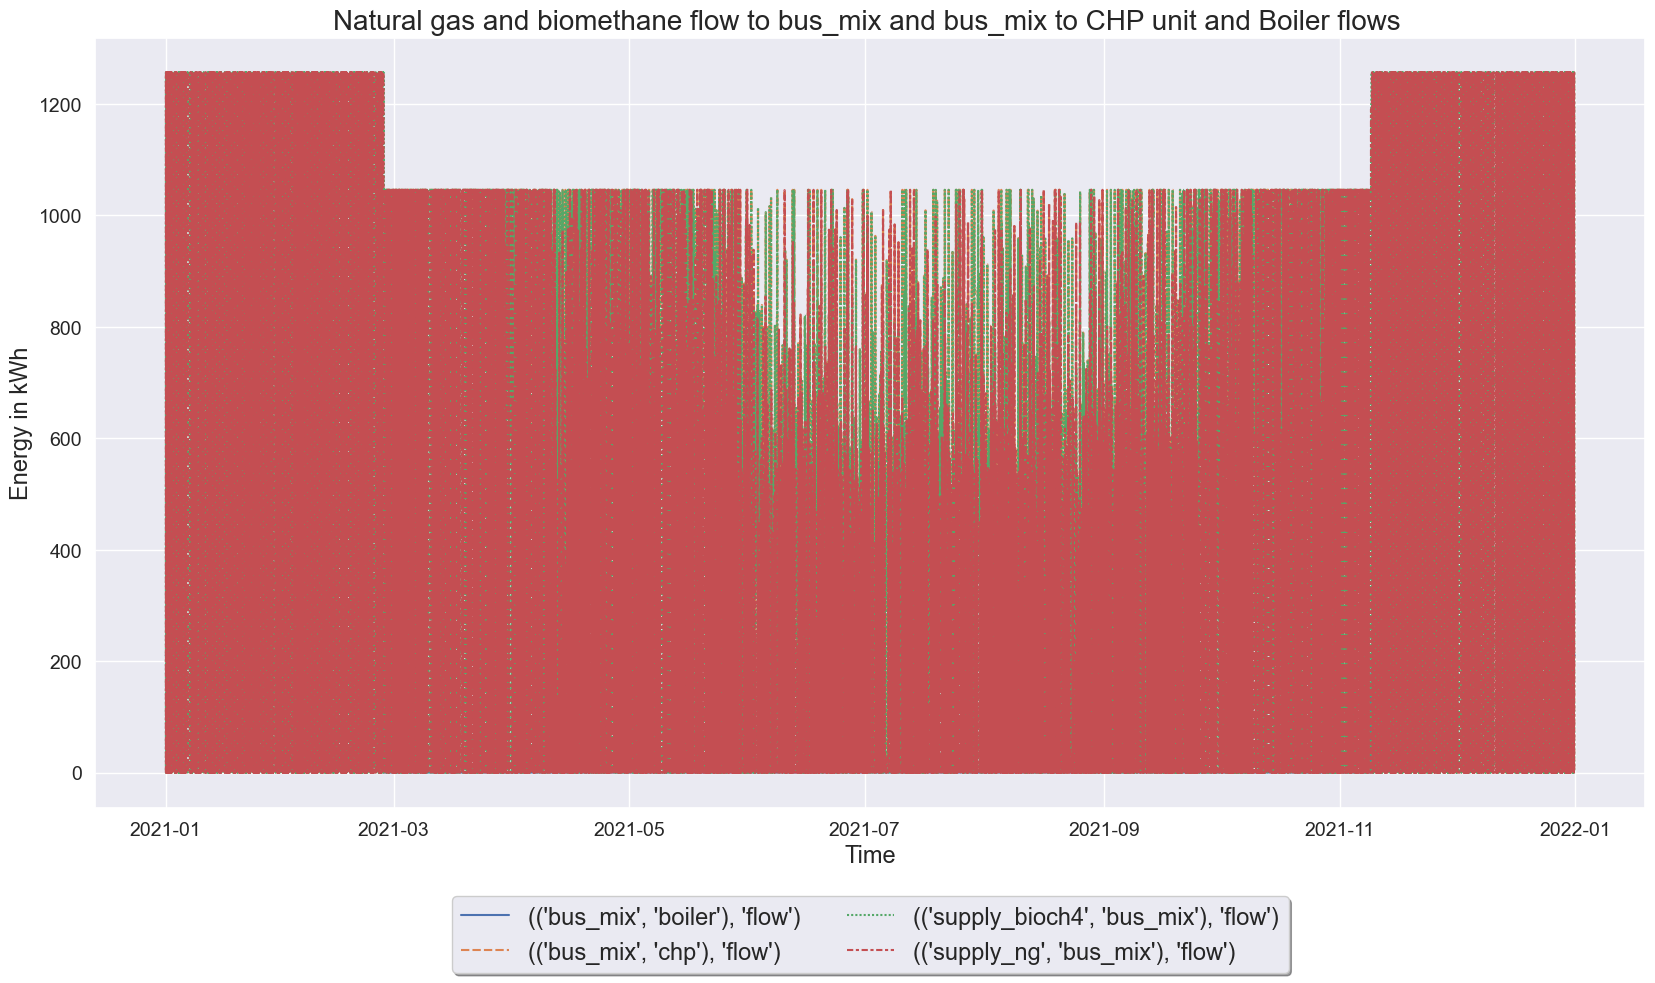

In [24]:
# Read results
plt.figure(figsize=(20,10))
profiles = solph.processing.results(om_con)
rbus_mix = solph.views.node(profiles,'bus_mix')['sequences']

sns.set(style='darkgrid')
plot = sns.lineplot(data=rbus_mix, drawstyle='steps-post')
plt.title('Natural gas and biomethane flow to bus_mix and bus_mix to CHP unit and Boiler flows ', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.2 Boiler input and output

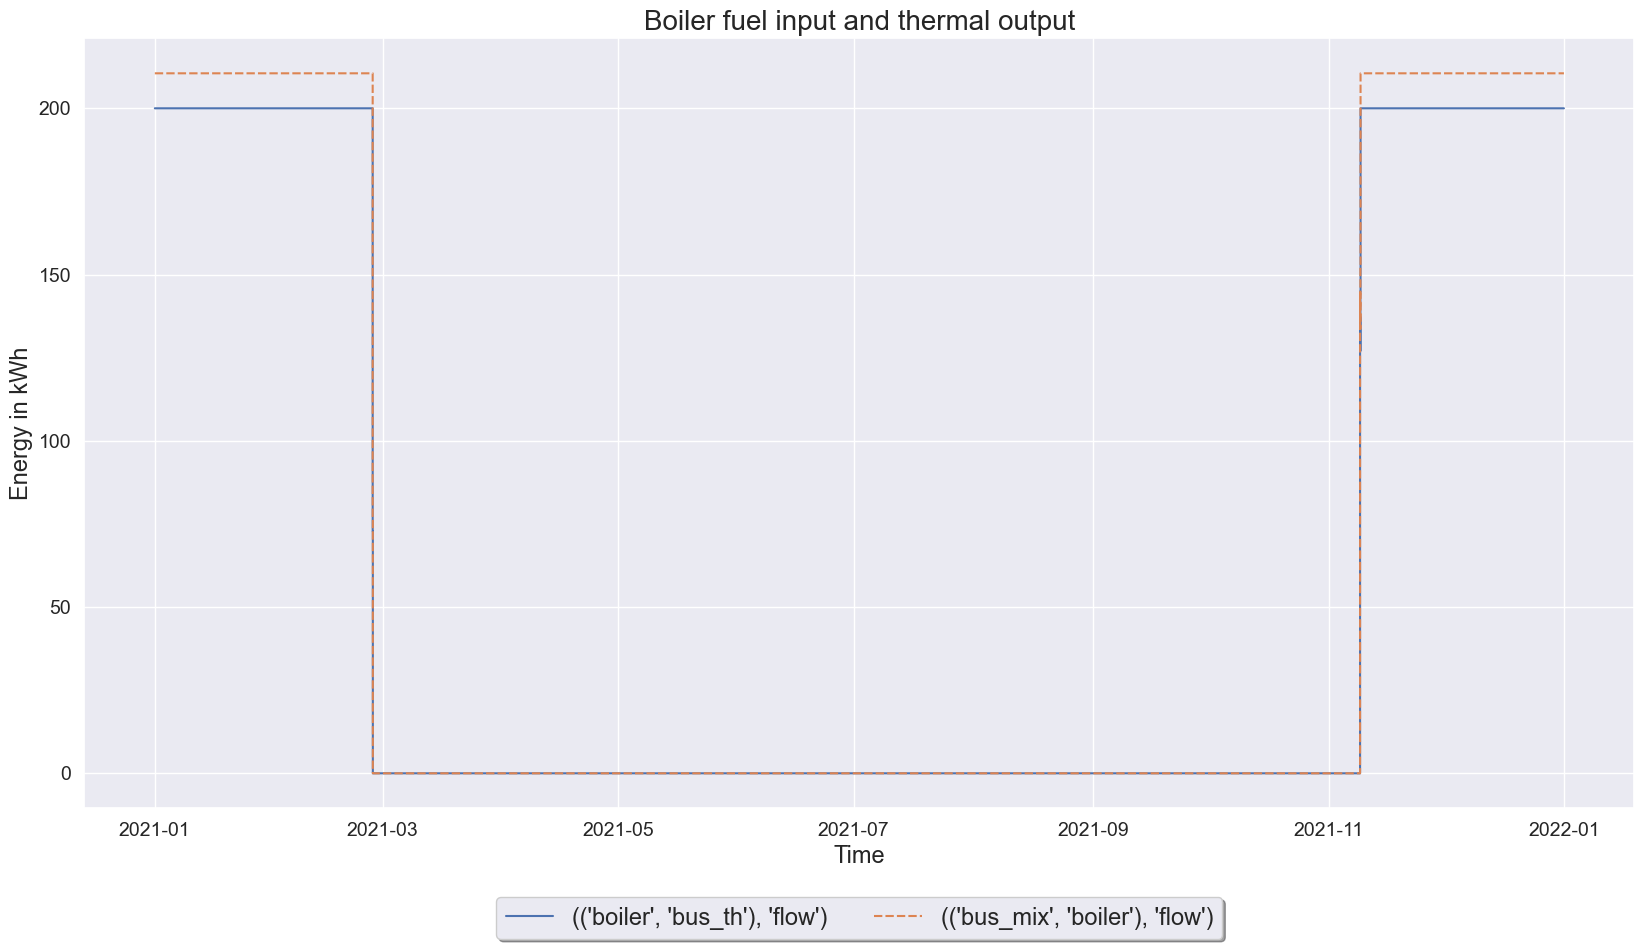

In [25]:
# Read results
plt.figure(figsize=(20,10))
profiles = solph.processing.results(om_con)
rboiler = solph.views.node(profiles,'boiler')['sequences']

#plot_color = 'red'
sns.set(style='darkgrid')
plot = sns.lineplot(data=rboiler, drawstyle='steps-post')
plt.title('Boiler fuel input and thermal output', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.3 CHP unit input and output

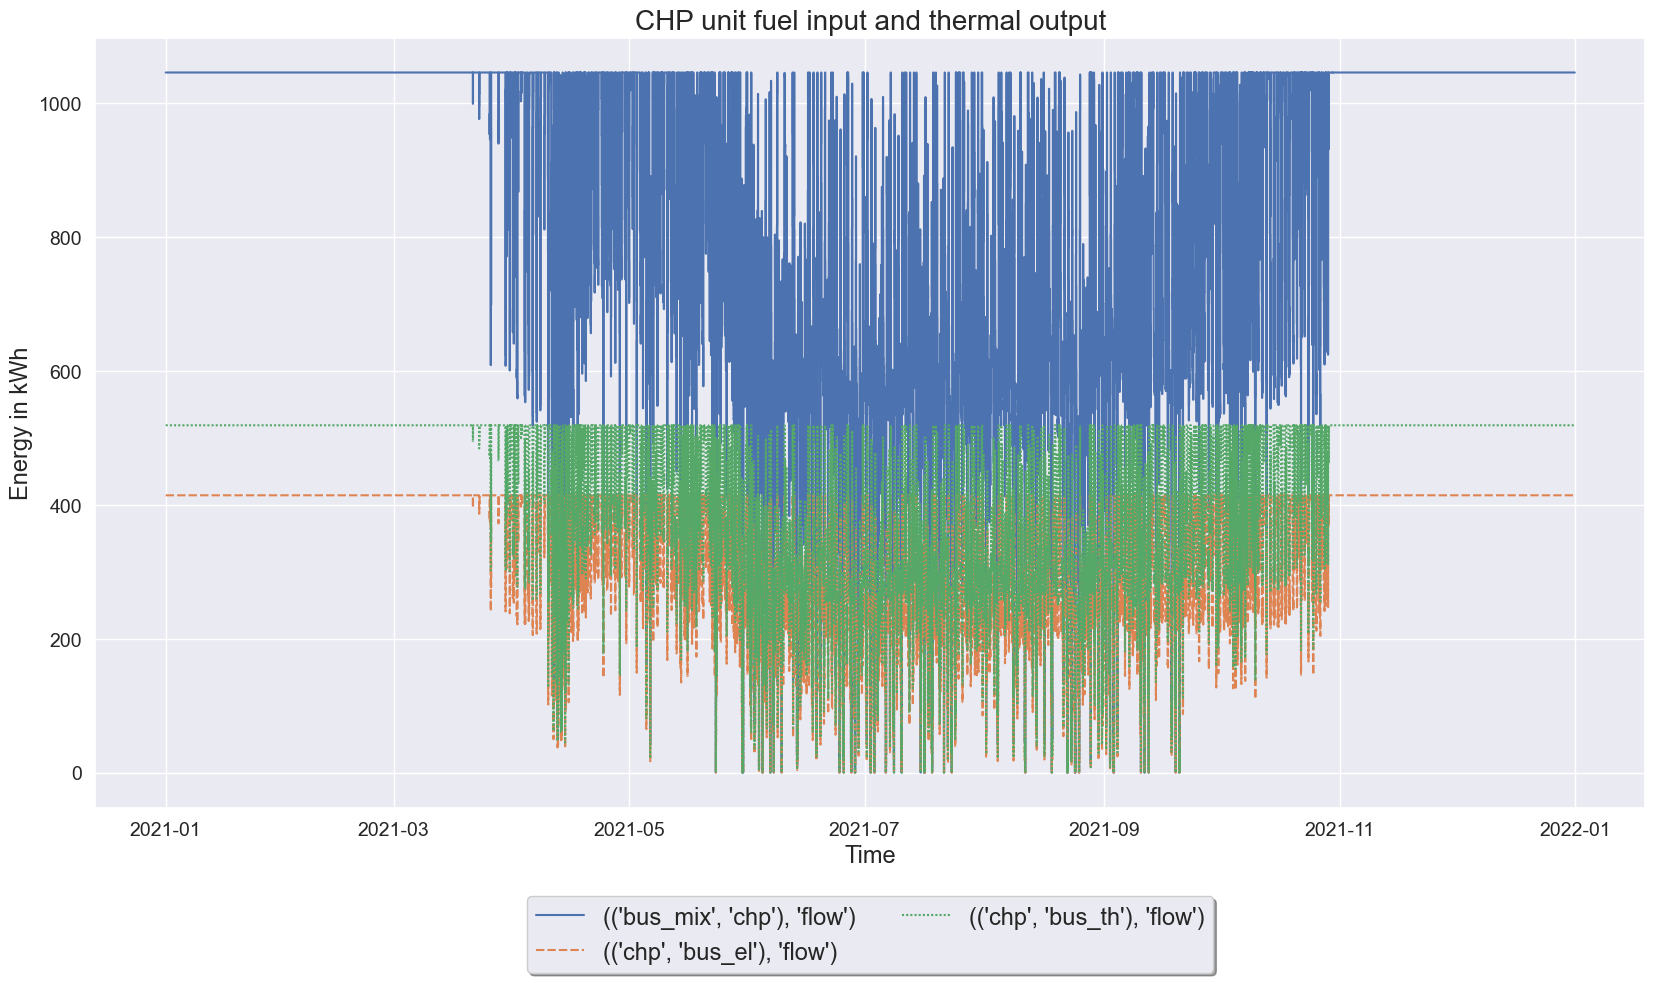

In [26]:
# Read results
plt.figure(figsize=(20,10))
profiles = solph.processing.results(om_con)
rchp = solph.views.node(profiles,'chp')['sequences']

#plot_color = 'red'
sns.set(style='darkgrid')
plot = sns.lineplot(data=rchp, drawstyle='steps-post')
plt.title('CHP unit fuel input and thermal output', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.4 Heat Pump input and output

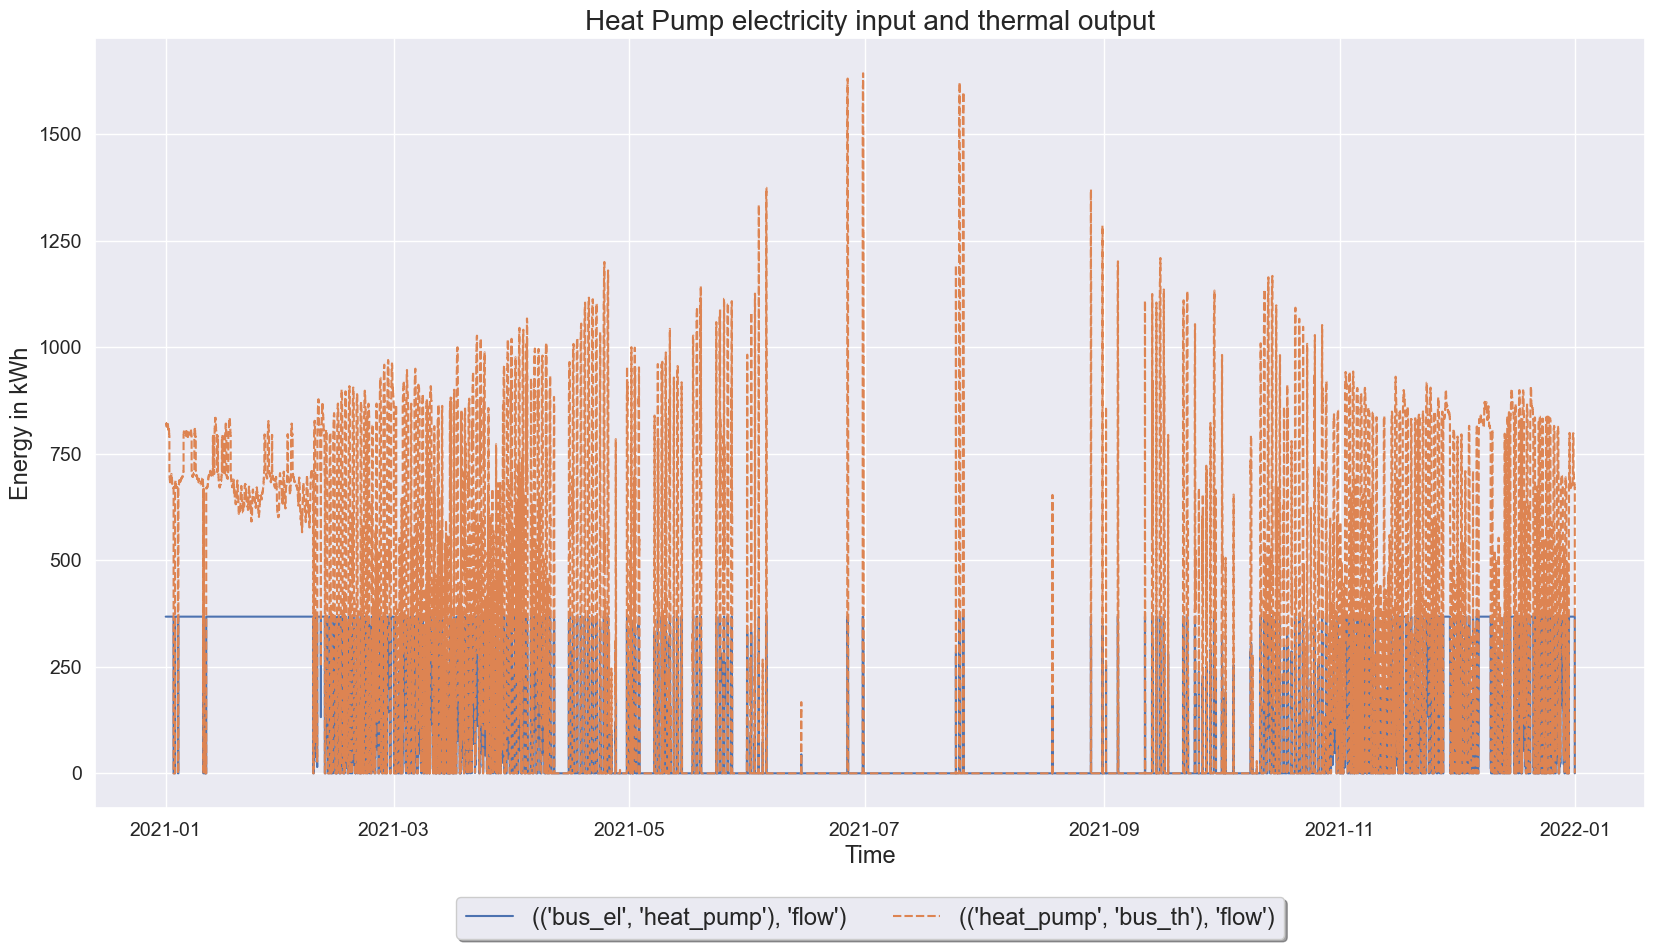

In [27]:
# Read results
plt.figure(figsize=(20,10))
profiles = solph.processing.results(om_con)
rheat_pump= solph.views.node(profiles,'heat_pump')['sequences']

#plot_color = 'red'
sns.set(style='darkgrid')
plot = sns.lineplot(data=rheat_pump, drawstyle='steps-post')
plt.title('Heat Pump electricity input and thermal output', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.5 Solar PV power plant

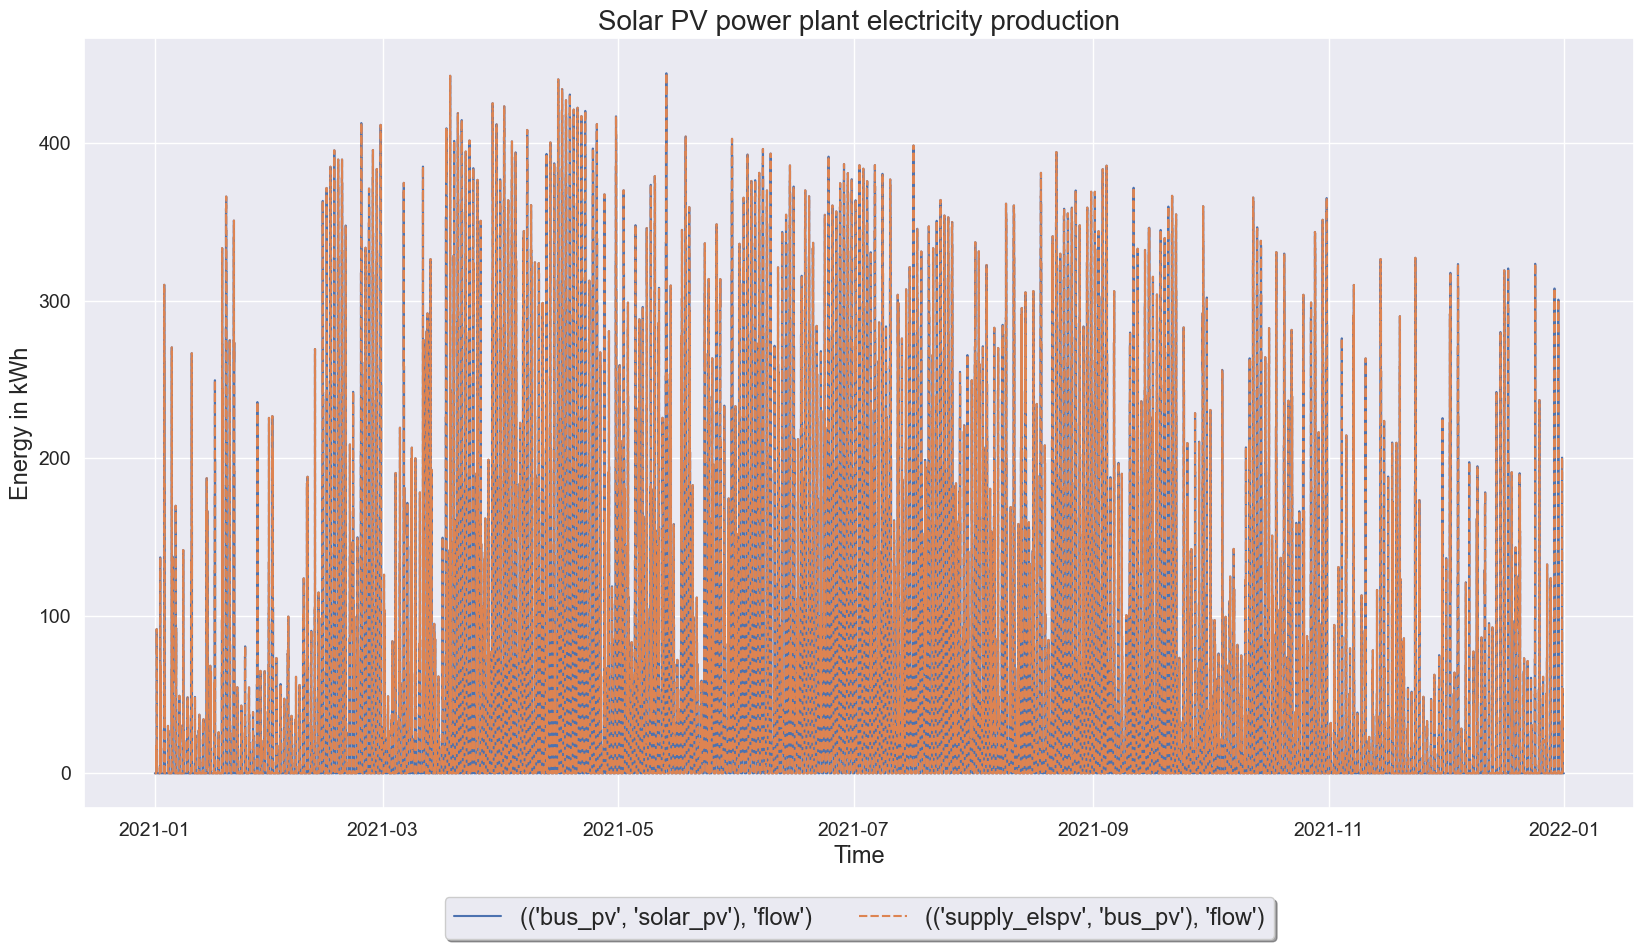

In [28]:
# Read results
plt.figure(figsize=(20,10))
profiles = solph.processing.results(om_con)
rbus_pv = solph.views.node(profiles,'bus_pv')['sequences']

#plot_color = 'red'
sns.set(style='darkgrid')
plot = sns.lineplot(data=rbus_pv, drawstyle='steps-post')
plt.title('Solar PV power plant electricity production', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.6 Thermal bus

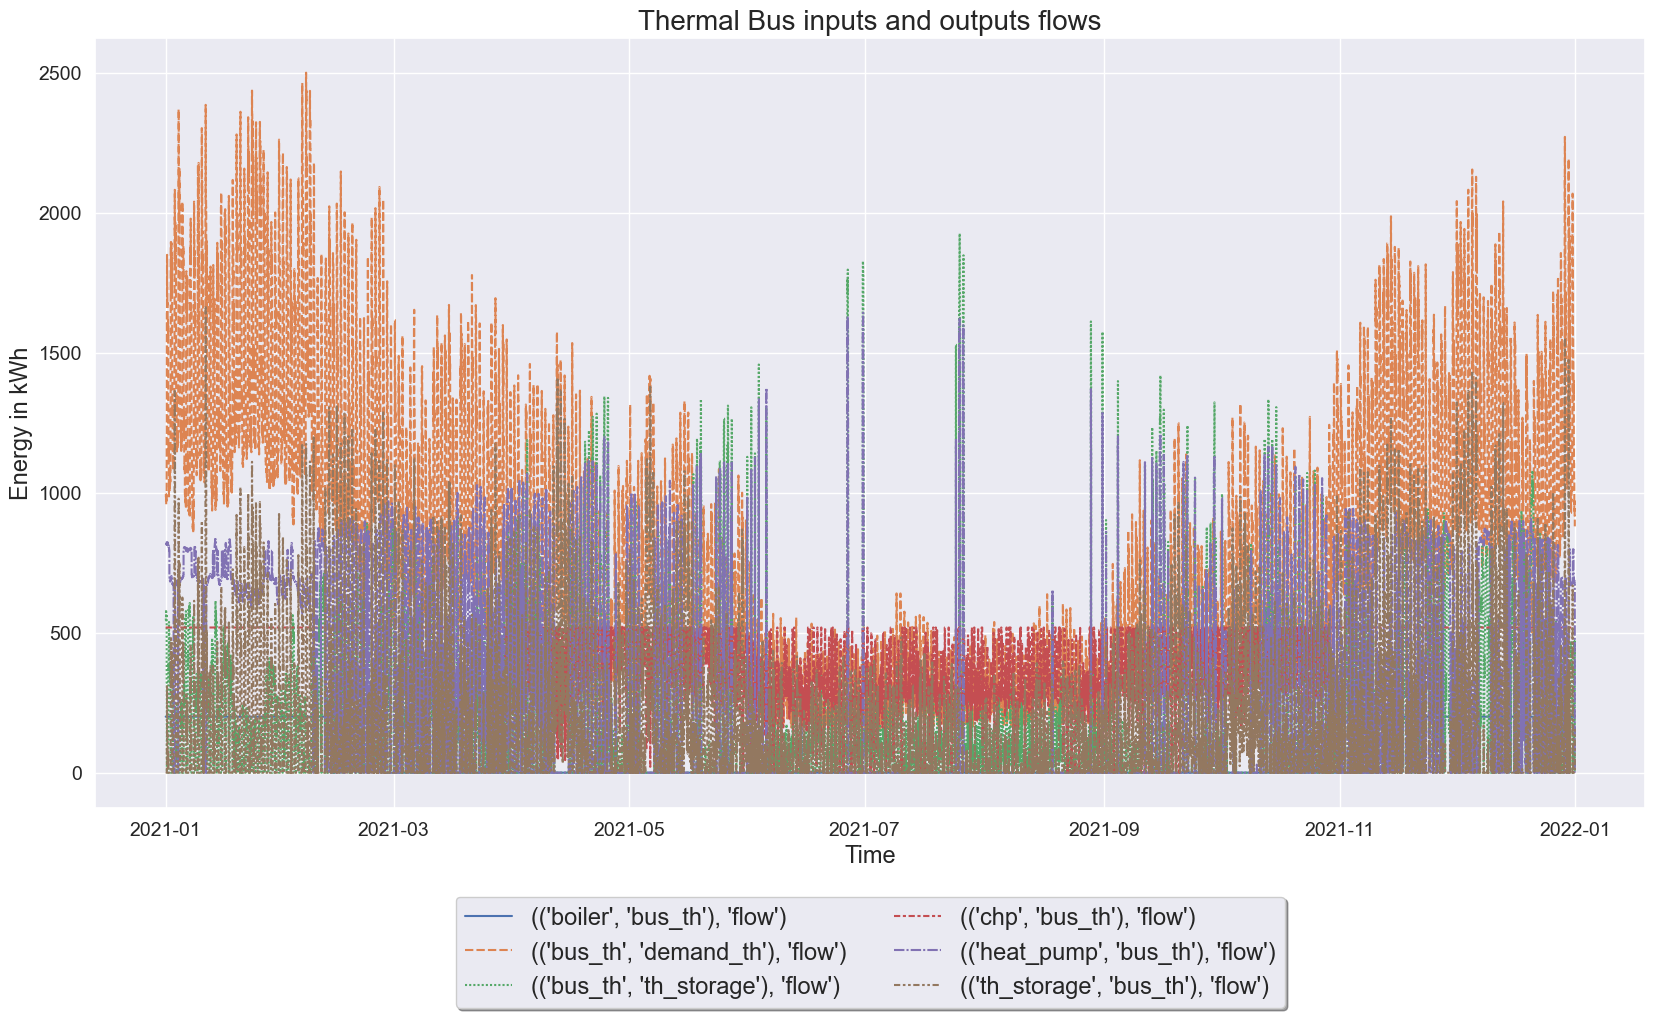

In [29]:
# Read results
plt.figure(figsize=(20,10))
profiles = solph.processing.results(om_con)
rbus_th = solph.views.node(profiles,'bus_th')['sequences']

#plot_color = 'red'
sns.set(style='darkgrid')
plot = sns.lineplot(data=rbus_th, drawstyle='steps-post')
plt.title('Thermal Bus inputs and outputs flows', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.5 Electric bus

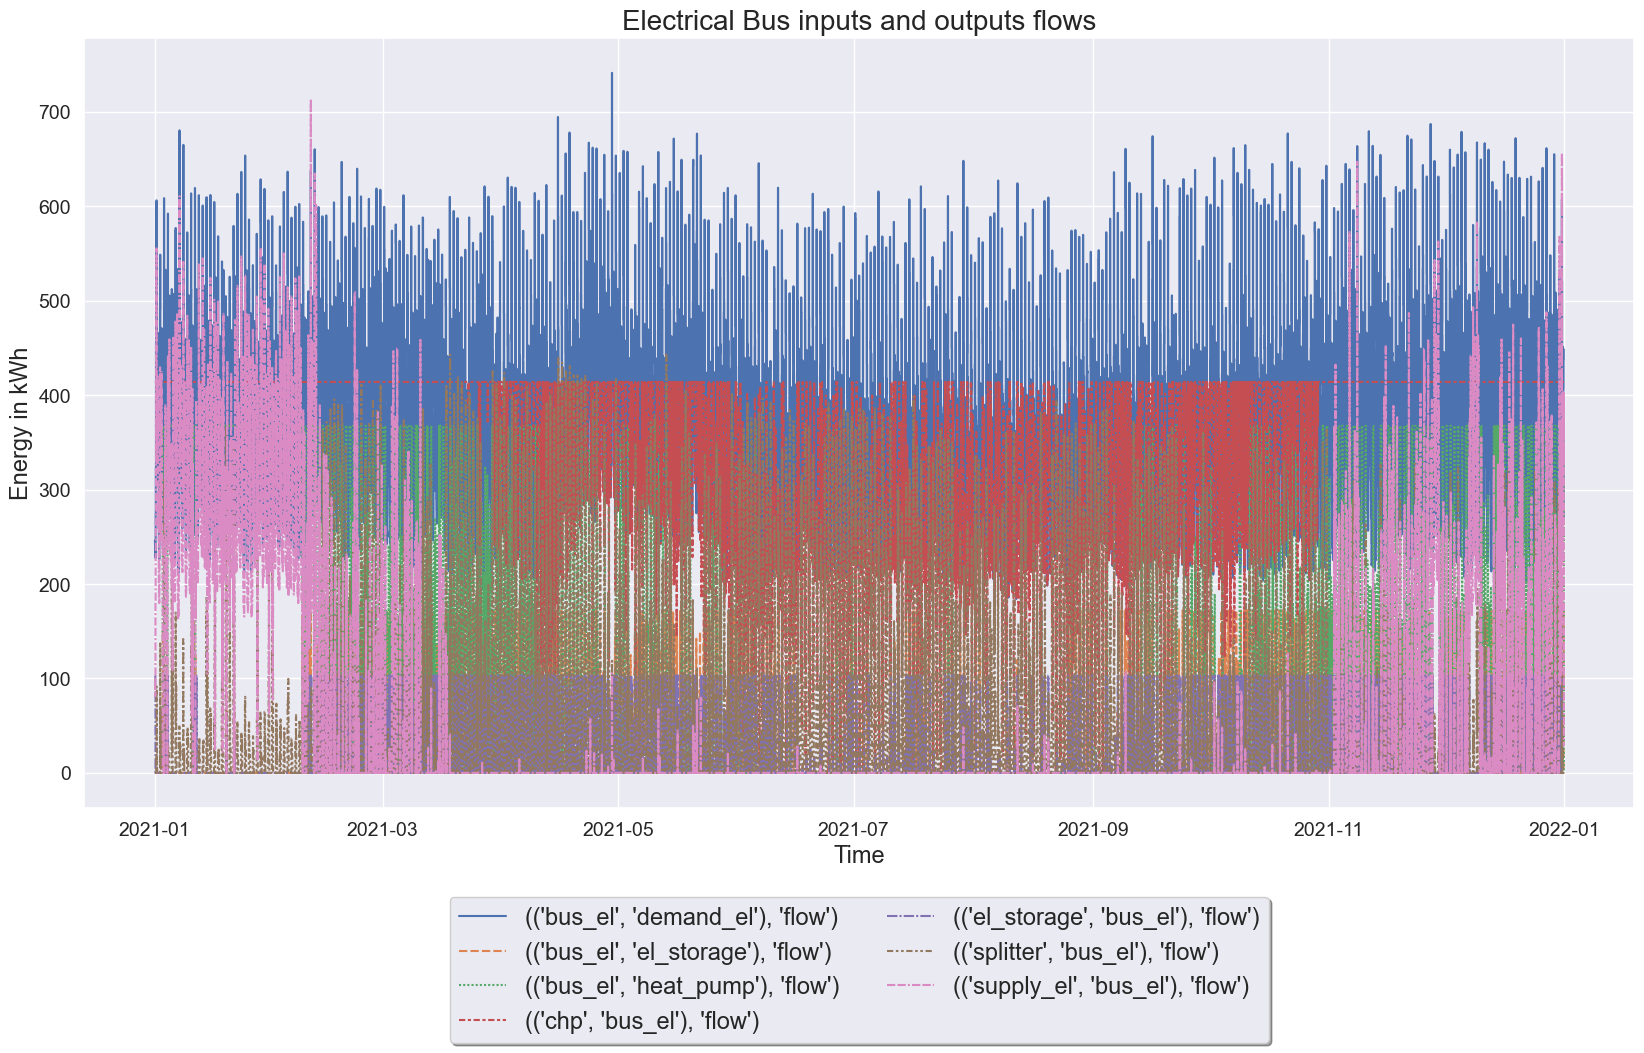

In [30]:
# Read results
plt.figure(figsize=(20,10))
profiles = solph.processing.results(om_con)
rbus_el = solph.views.node(profiles,'bus_el')['sequences']

#plot_color = 'red'
sns.set(style='darkgrid')
plot = sns.lineplot(data=rbus_el, drawstyle='steps-post')
plt.title('Electrical Bus inputs and outputs flows', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.6 Electric storage

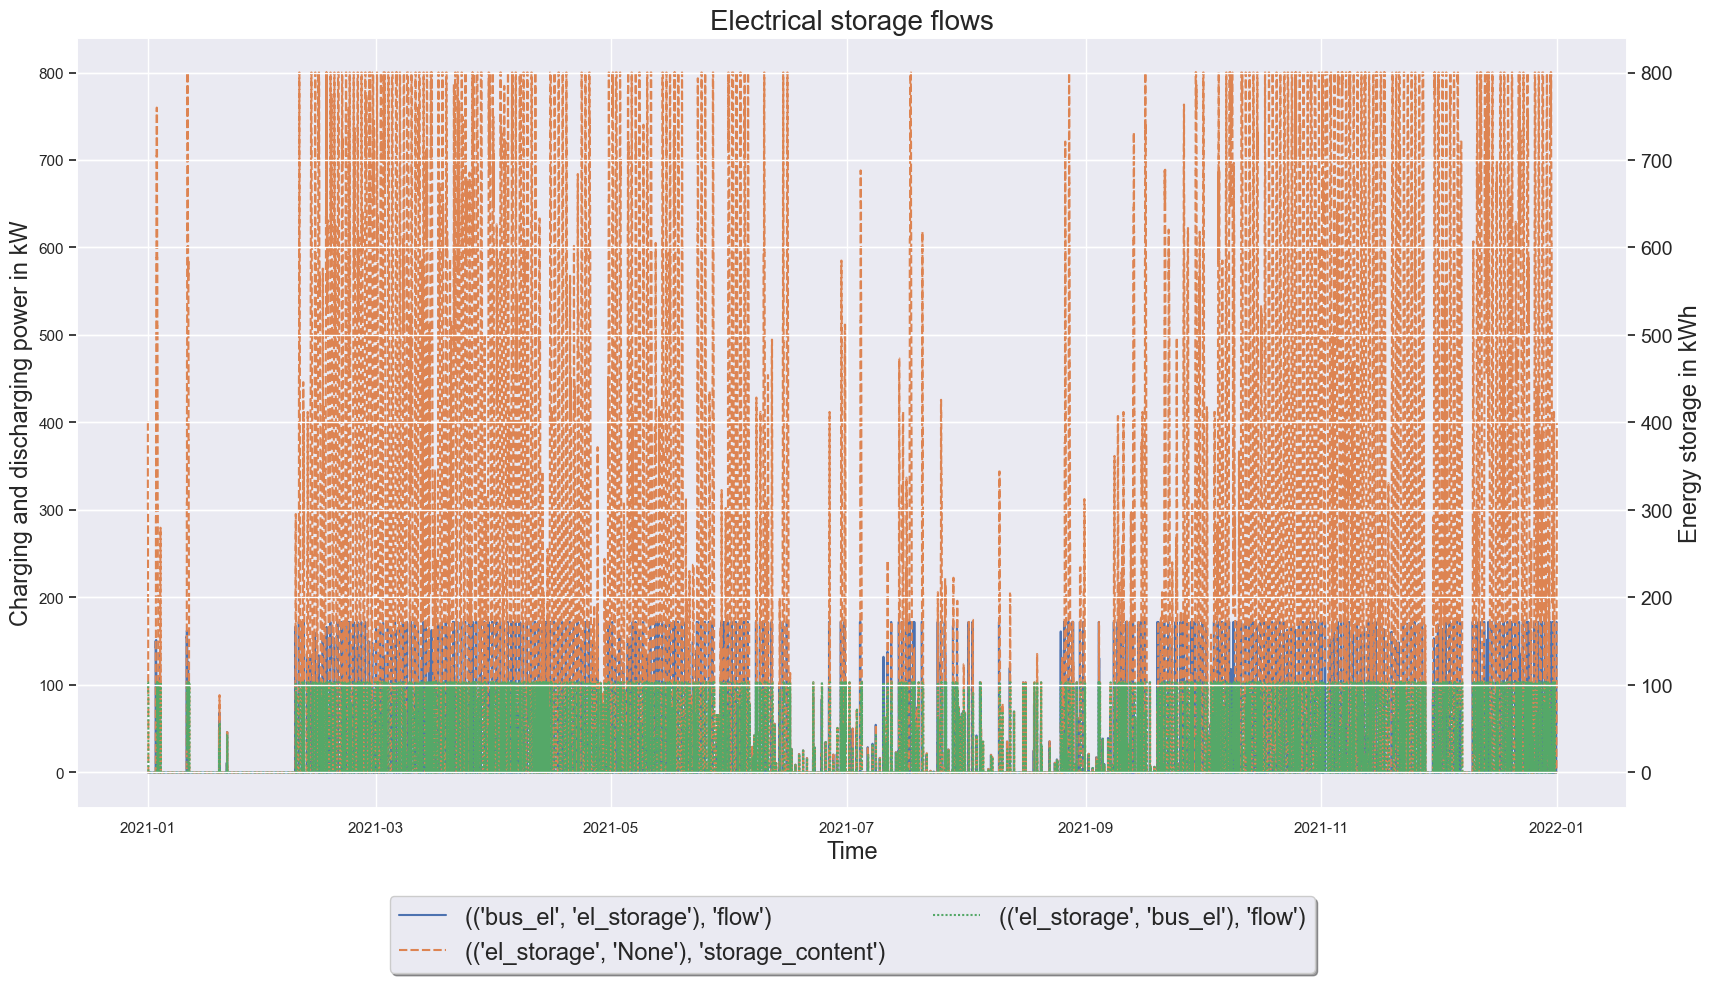

In [31]:
plt.figure(figsize=(20, 10))
profiles = solph.processing.results(om_con)
rel_storage = solph.views.node(profiles, 'el_storage')['sequences']

sns.set(style='darkgrid')
ax1 = sns.lineplot(data=rel_storage, drawstyle='steps-post')
plt.title('Electrical storage flows', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Charging and discharging power in kW', fontsize=17)

# Create a twin axis for the right y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Energy storage in kWh', fontsize=17)

# Set the limits for the right y-axis to match the left y-axis
ax2.set_ylim(ax1.get_ylim())

# Add legend
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)

# Set tick font sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

#### 9.6 Thermal storage

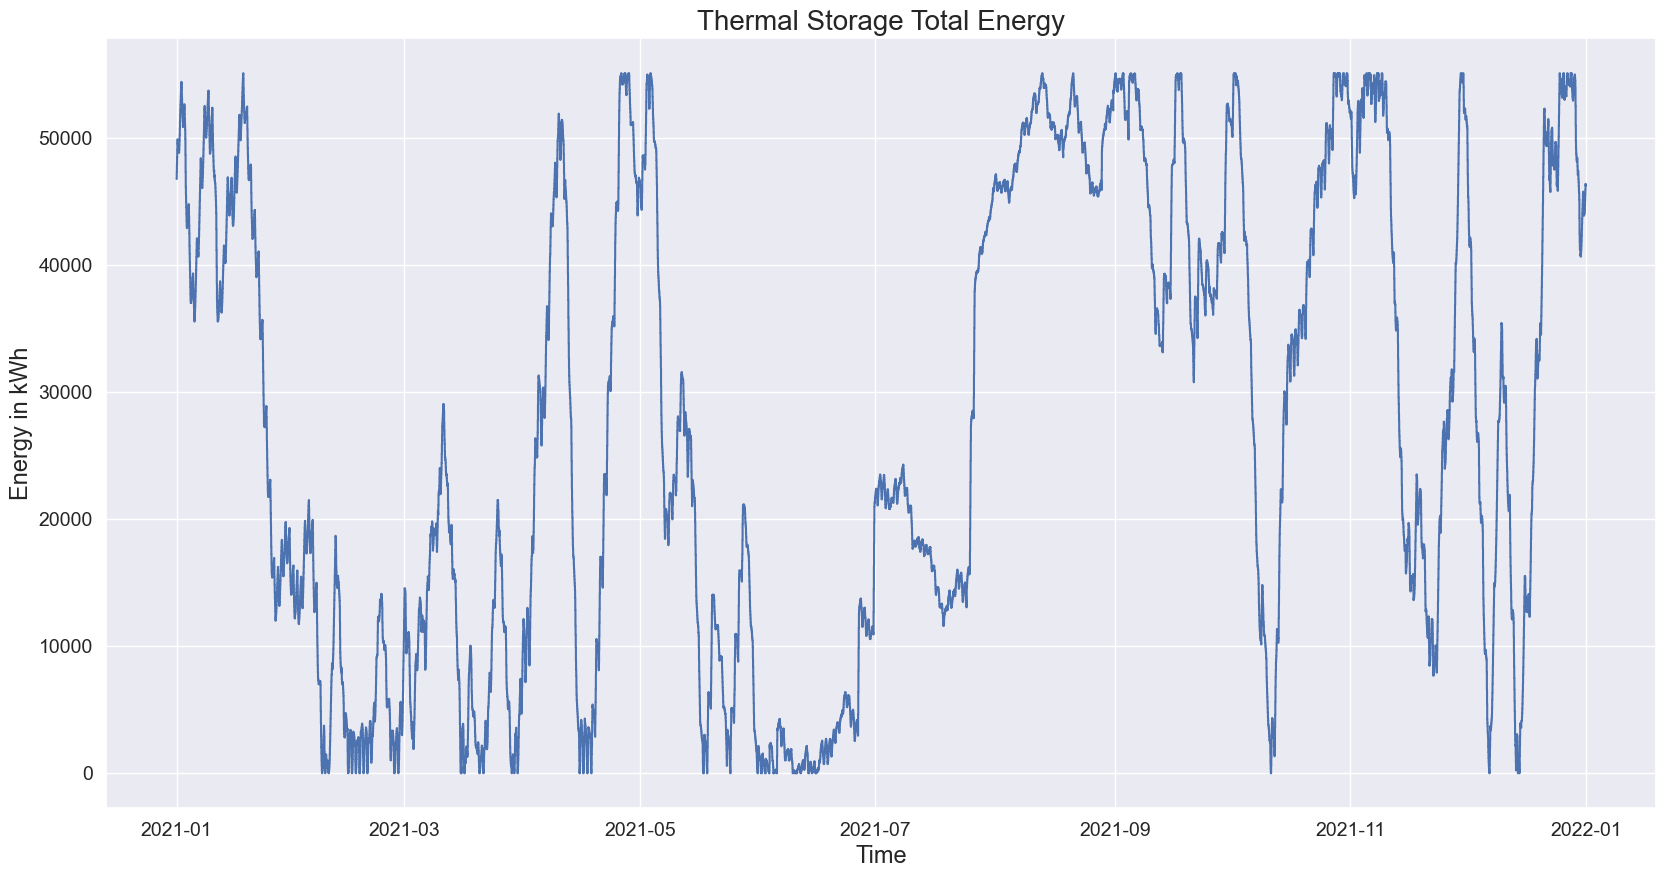

In [32]:
plt.figure(figsize=(20,10))
sns.set(style='darkgrid')
plot = sns.lineplot(data=res_stor_m, drawstyle='steps-post')
plt.title('Thermal Storage Total Energy', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Energy in kWh', fontsize=17)
#plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 9.6.1 Thermal Storage charging Discharging

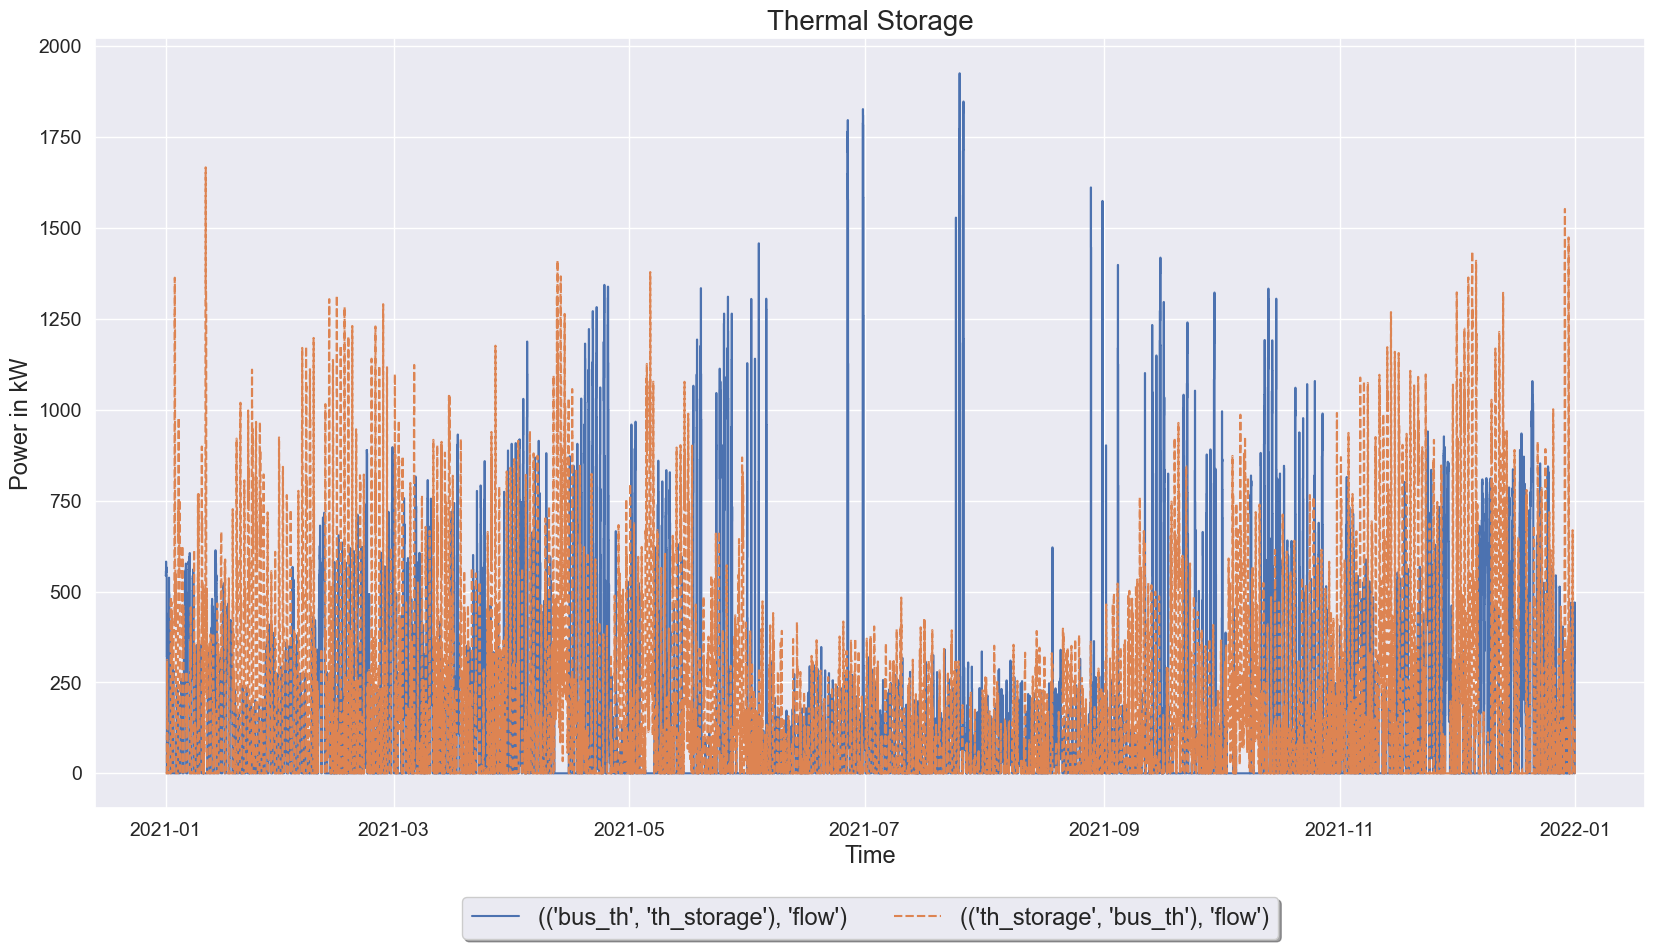

In [33]:
plt.figure(figsize=(20,10))
sns.set(style='darkgrid')
profiles = solph.processing.results(om_con)
rbus_th = solph.views.node(profiles, 'th_storage')['sequences']

# Check if the flow exists before attempting to drop it
flow_to_drop = (('th_storage', 'None'),'storage_content')
if flow_to_drop in rbus_th.columns:
    rbus_th_filtered = rbus_th.drop(flow_to_drop, axis=1)
else:
    rbus_th_filtered = rbus_th.copy()

plot = sns.lineplot(data=rbus_th_filtered, drawstyle='steps-post')
plt.title('Thermal Storage', fontsize=20)
plt.xlabel('Time', fontsize=17)
plt.ylabel('Power in kW', fontsize=17)
plot.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2, fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### 10. CAPEX


In [34]:
#CAPEX of Heat Pump
CAPEX_heat_pump = pow_elhp*hp_cost
print('CAPEX of the Heat Pump:                 {:.0f}  €'.format(CAPEX_heat_pump))

#CAPEX of CHP unit
CAPEX_chp = pow_elchp*gchp_cost
print('CAPEX of the CHP unit:                  {:.0f}  €'.format(CAPEX_chp))

#CAPEX of Boiler
CAPEX_boiler = pow_boiler*gboiler_cost
print('CAPEX of the Boiler:                    {:.0f}  €'.format(CAPEX_boiler))

#CAPEX of Solar PV power plant
CAPEX_solar_pv =(solarpv_cost+bos_cost)*pow_solarpv
print('CAPEX of the Solar PV power plant:      {:.0f}  €'.format(CAPEX_solar_pv))

#CAPEX of Thermal Storage
CAPEX_th_storage = th_store_cost*cap_th_store
print('CAPEX of the Thermal Storage:           {:.0f}  €'.format(CAPEX_th_storage))

#CAPEX of the Electrical Storage
CAPEX_el_storage = el_storage_cost*batt_store_cap
print('CAPEX of the Electrical Storage:        {:.0f}  €'.format(CAPEX_el_storage))

print('\n')
#TotalCAPEX
Total_CAPEX = CAPEX_heat_pump + CAPEX_chp + CAPEX_boiler + CAPEX_solar_pv + CAPEX_th_storage + CAPEX_el_storage    
print('Total CAPEX of the Energy System:       {:.0f}  €'.format(Total_CAPEX))


CAPEX of the Heat Pump:                 552000  €
CAPEX of the CHP unit:                  310500  €
CAPEX of the Boiler:                    30000  €
CAPEX of the Solar PV power plant:      487500  €
CAPEX of the Thermal Storage:           165328  €
CAPEX of the Electrical Storage:        105600  €


Total CAPEX of the Energy System:       1650928  €


#### 10.1 CAPEX Thermal

In [35]:
#CAPEX of Heat Pump
print('CAPEX of the Heat Pump:                                           {:.0f}  €'.format(CAPEX_heat_pump))

#CAPEX of CHP unit, thermal share
total_energy_chp = chp_to_bus_th+chp_to_bus_el   #Total energy generated by the CHP unit
share_th=chp_to_bus_th/total_energy_chp          #Percentage of thermal energy generated by the CHP unit      
share_el=chp_to_bus_el/total_energy_chp          #Percentage of electrical energy generated by the CHP unit

#share of electricity that goes to the heat pump from CHP unit
pro_supply_el_to_heat_pump = bus_el_to_heat_pump/(bus_el_to_heat_pump+bus_el_to_demand_el)

CAPEXth_chp = CAPEX_chp*share_th
CAPEXel_chp_to_heat_pump=CAPEX_chp*share_el*pro_supply_el_to_heat_pump
print('CAPEX of the CHP unit to generate thermal:                        {:.0f}  €'.format(CAPEXth_chp+CAPEXel_chp_to_heat_pump))

#CAPEX of Boiler
print('CAPEX of the Boiler:                                              {:.0f}  €'.format(CAPEX_boiler))

#CAPEX of Solar PV power plant
CAPEX_thsolar_pv =(solarpv_cost+bos_cost)*pow_solarpv*pro_supply_el_to_heat_pump
print('Share of CAPEX of the Solar PV power plant to generate thermal :  {:.0f}  €'.format(CAPEX_thsolar_pv))

#CAPEX of Thermal Storage
print('CAPEX of the Thermal Storage:                                     {:.0f}  €'.format(CAPEX_th_storage))

#CAPEX of the Electrical Storage
CAPEX_thel_storage = el_storage_cost*batt_store_cap*pro_supply_el_to_heat_pump
print('Share of CAPEX of the Electrical Storage to generate thermal:     {:.0f}  €'.format(CAPEX_thel_storage))

print('\n')
#TotalCAPEX
Total_thCAPEX = CAPEX_heat_pump+CAPEXth_chp+CAPEXel_chp_to_heat_pump+CAPEX_boiler+CAPEX_thsolar_pv+CAPEX_th_storage+CAPEX_thel_storage    
print('Total thermal CAPEX of the Energy System:                         {:.0f}  €'.format(Total_thCAPEX))


CAPEX of the Heat Pump:                                           552000  €
CAPEX of the CHP unit to generate thermal:                        207223  €
CAPEX of the Boiler:                                              30000  €
Share of CAPEX of the Solar PV power plant to generate thermal :  122253  €
CAPEX of the Thermal Storage:                                     165328  €
Share of CAPEX of the Electrical Storage to generate thermal:     26482  €


Total thermal CAPEX of the Energy System:                         1103285  €


#### 10.1.1 CAPEX Electrical

In [36]:
#CAPEX electrical components

#CAPEX of CHP unit, Electrical share
total_energy_chp = chp_to_bus_th+chp_to_bus_el   #Total energy generated by the CHP unit
share_th=chp_to_bus_th/total_energy_chp          #Percentage of thermal energy generated by the CHP unit      
share_el=chp_to_bus_el/total_energy_chp          #Percentage of electrical energy generated by the CHP unit

#share of electricity that goes to the heat pump from CHP unit
pro_supply_el_to_demand_el = bus_el_to_demand_el/(bus_el_to_heat_pump+bus_el_to_demand_el)

CAPEXel_chp = CAPEX_chp*share_el*pro_supply_el_to_demand_el
print('CAPEX of the CHP unit to generate Electrical:                        {:.0f}  €'.format(CAPEXel_chp))


#CAPEX of Solar PV power plant
CAPEX_elsolar_pv =(solarpv_cost+bos_cost)*pow_solarpv*pro_supply_el_to_demand_el
print('Share of CAPEX of the Solar PV power plant to generate Electrical :  {:.0f}  €'.format(CAPEX_thsolar_pv))


#CAPEX of the Electrical Storage
CAPEX_el_storage = el_storage_cost*batt_store_cap*pro_supply_el_to_demand_el
print('Share of CAPEX of the Electrical Storage to generate Electrical:     {:.0f}  €'.format(CAPEX_thel_storage))

print('\n')
#TotalCAPEX
Total_elCAPEX = CAPEXel_chp+CAPEX_elsolar_pv+CAPEX_el_storage    
print('Total Electrical CAPEX of the Electrical System:                     {:.0f}  €'.format(Total_elCAPEX))


CAPEX of the CHP unit to generate Electrical:                        103277  €
Share of CAPEX of the Solar PV power plant to generate Electrical :  122253  €
Share of CAPEX of the Electrical Storage to generate Electrical:     26482  €


Total Electrical CAPEX of the Electrical System:                     547643  €


#### 11. OPEX 

#### 11.1 OPEX natural gas

In [37]:
# Natural gas OPEX
supply_ng_output = rbus_mix[(('supply_ng', 'bus_mix'), 'flow')].sum()
print('Natural gas demand:                                    {:.0f} kWh'.format(supply_ng_output))

share_ng_bus_mix = supply_ng_output/(supply_ng_output+supply_bioch4_to_bus_mix)

## bus_mix to CHP unit
bus_mix_to_chp= share_ng_bus_mix*rbus_mix[(('bus_mix', 'chp'), 'flow')].sum()
print ('Natural gas from bus_mix to chp:                       {:.0f} kWh'.format(bus_mix_to_chp))

## share of the natural gas used in the CHP unit to produce thermal energy
share_ngth=share_ng_bus_mix*bus_mix_to_chp*share_th
share_ngel=share_ng_bus_mix*bus_mix_to_chp*share_el
share_ngel_to_heat_pump=share_ngel*pro_supply_el_to_heat_pump


# Share of the natural gas used in the CHP unit to produce thermal energy in the heath pump 
OPEX_supply_ng_thchp = share_ngth*ng_price/100
OPEX_supply_ng_elchp_to_heath_pump= share_ngel_to_heat_pump*ng_price/100
print('OPEX Natural Gas CHP unit:                              {:.0f}  €'.format(OPEX_supply_ng_thchp+OPEX_supply_ng_elchp_to_heath_pump))

print('\n')
## bus_mix to boiler
bus_mix_to_boiler=  share_ng_bus_mix*rbus_mix[(('bus_mix', 'boiler'), 'flow')].sum()
print ('Natural gas from bus_mix to boiler:                    {:.0f} kWh'.format(bus_mix_to_boiler))
OPEX_supply_ng_boiler =bus_mix_to_boiler*ng_price/100
print('OPEX Natural Gas boiler:                                {:.0f}  €'.format(OPEX_supply_ng_boiler))

print('\n')
#Total OPEX
Total_OPEX_ng = OPEX_supply_ng_thchp + OPEX_supply_ng_elchp_to_heath_pump + OPEX_supply_ng_boiler
print('Total thermal Natural gas OPEX  of the Energy System:   {:.0f}  €'.format(Total_OPEX_ng))

Natural gas demand:                                    2853730 kWh
Natural gas from bus_mix to chp:                       2658527 kWh
OPEX Natural Gas CHP unit:                              50206  €


Natural gas from bus_mix to boiler:                    195203 kWh
OPEX Natural Gas boiler:                                15616  €


Total thermal Natural gas OPEX  of the Energy System:   65822  €


#### 11.1.1 OPEX Electrical

In [38]:
#OPEX electrical components
#OPEX Electrical Grid
OPEX_elgrid= supply_el_to_bus_el*pro_supply_el_to_demand_el*(el_lc_price/100)
print('OPEX of Grid Electrical:                                            {:.0f}  €'.format(OPEX_elgrid))

#OPEX of CHP unit, Electrical share
total_energy_chp = chp_to_bus_th+chp_to_bus_el   #Total energy generated by the CHP unit
share_th=chp_to_bus_th/total_energy_chp          #Percentage of thermal energy generated by the CHP unit      
share_el=chp_to_bus_el/total_energy_chp          #Percentage of electrical energy generated by the CHP unit

#share of electricity that goes to the heat pump from CHP unit
pro_supply_el_to_demand_el = bus_el_to_demand_el/(bus_el_to_heat_pump+bus_el_to_demand_el)

OPEXel_chp_ng =(supply_ng_to_bus_mix-bus_mix_to_boiler)*share_el*pro_supply_el_to_demand_el*(ng_price/100)
print('OPEX of the CHP unit to generate Electrical:                         {:.0f}  €'.format(OPEXel_chp_ng))

OPEXel_chp_bch4 =(supply_bioch4_to_bus_mix-bus_mix_to_boiler)*share_el*pro_supply_el_to_demand_el*(ng_price/100)
print('OPEX of the CHP unit to generate Electrical:                        {:.0f}  €'.format(OPEXel_chp_bch4))


print('\n')
#Total OPEX
Total_elOPEX = OPEXel_chp_bch4+OPEXel_chp_ng+OPEX_elgrid   
print('Total Electrical OPEX of the Energy System:                         {:.0f}  €'.format(Total_elOPEX))

OPEX of Grid Electrical:                                            120379  €
OPEX of the CHP unit to generate Electrical:                         70741  €
OPEX of the CHP unit to generate Electrical:                        133554  €


Total Electrical OPEX of the Energy System:                         324674  €


#### 11.2 OPEX Biomethane

In [39]:
# Biomethane gas OPEX
supply_bioch4_output = rbus_mix[(('supply_bioch4', 'bus_mix'), 'flow')].sum()
print('Biomethane demand:                                      {:.0f} kWh'.format(supply_bioch4_output))

share_bioch4_bus_mix = supply_bioch4_to_bus_mix/(supply_ng_output+supply_bioch4_to_bus_mix)

## bus_mix to CHP unit
bus_mix_to_chp= share_bioch4_bus_mix*rbus_mix[(('bus_mix', 'chp'), 'flow')].sum()
print ('Biomethane from bus_mix to chp:                        {:.0f} kWh'.format(bus_mix_to_chp))

## share of biomethane gas used in the CHP unit to produce thermal energy
share_bioch4th=share_bioch4_bus_mix*bus_mix_to_chp*share_th
share_bioch4el=share_bioch4_bus_mix*bus_mix_to_chp*share_el
share_bioch4el_to_heat_pump=share_bioch4el*pro_supply_el_to_heat_pump

# Share of the natural gas used in the CHP unit to produce thermal energy in the heath pump 
OPEX_supply_bioch4_thchp = share_bioch4th*BCH4_price/100
OPEX_supply_bioch4_elchp_to_heath_pump= share_bioch4el_to_heat_pump*BCH4_price/100
print('OPEX Biomethane CHP unit:                               {:.0f}  €'.format(OPEX_supply_bioch4_thchp+OPEX_supply_bioch4_elchp_to_heath_pump))

print('\n')
## bus_mix to boiler
bus_mix_to_boiler=  share_bioch4_bus_mix*rbus_mix[(('bus_mix', 'boiler'), 'flow')].sum()
print ('Biomethane from bus_mix to boiler:                     {:.0f} kWh'.format(bus_mix_to_boiler))
OPEX_supply_bioch4_boiler =bus_mix_to_boiler*BCH4_price/100
print('OPEX Biomethane boiler:                                 {:.0f}  €'.format(OPEX_supply_bioch4_boiler))

print('\n')
#Total OPEX
Total_OPEX_bioch4 = OPEX_supply_bioch4_thchp+OPEX_supply_bioch4_elchp_to_heath_pump +OPEX_supply_bioch4_boiler
print('Total thermal Biomethane OPEX of the Energy System:     {:.0f}  €'.format(Total_OPEX_bioch4))


Biomethane demand:                                      5214287 kWh
Biomethane from bus_mix to chp:                        4857615 kWh
OPEX Biomethane CHP unit:                               314281  €


Biomethane from bus_mix to boiler:                     356672 kWh
OPEX Biomethane boiler:                                 53501  €


Total thermal Biomethane OPEX of the Energy System:     367782  €


#### 11.3 OPEX electricty to heat pump

In [40]:
# supply_el to bus_el
supply_el_to_bus_el=  rbus_el[(('supply_el', 'bus_el'), 'flow')].sum()
print ('Electricity from public power grid to_bus_el:             {:.0f} kWh'.format(supply_el_to_bus_el))

OPEX_el_from_supply_el_to_bus_el =supply_el_to_bus_el*pro_supply_el_to_heat_pump*el_lc_price/100 
print ('OPEX electricity from the grid:                           {:.0f} €'.format(OPEX_el_from_supply_el_to_bus_el))


Electricity from public power grid to_bus_el:             446308 kWh
OPEX electricity from the grid:                           40292 €


#### 11.4 Total Opex

In [41]:
Total_OPEX = Total_OPEX_ng + Total_OPEX_bioch4+ OPEX_el_from_supply_el_to_bus_el
print ('Total OPEX:                           {:.0f} €'.format(Total_OPEX))

Total OPEX:                           473896 €


#### 12. Revenues

In [42]:
print ('Electricity from solar pv power plant to the public grid:   {:.0f} kWh'.format(bus_gridfeed_to_pgrid_el))
revenue= bus_gridfeed_to_pgrid_el*(rev_solarpv/100)
print('Revenue from PV Electricty sold to grid:                   {:.0f} €'.format(revenue))

Electricity from solar pv power plant to the public grid:   0 kWh
Revenue from PV Electricty sold to grid:                   -0 €


#### 13. Total Eenergy Ouput(Electrical and Thermical) 

In [43]:
#Total Energy output of the system
Total_Energy = bus_el_to_demand_el+bus_th_to_demand_th
print ('Total_Energy: {:.0f} kWh'.format(Total_Energy))


Total_Energy: 9478609 kWh


#### 14. LCOE Thermal

In [44]:
# Total cost asociated to thermal generation
Total_thermal_cost = Total_thCAPEX + Total_OPEX + revenue
Total_heat_energy = bus_th_to_demand_th
LCEO_th = Total_thermal_cost/bus_th_to_demand_th
print ('LCOE thermal generation: {:.4f} €/kWh'.format(LCEO_th))
print ('LCOE thermal generation: {:.2f} ct/kWh'.format(LCEO_th*100))

LCOE thermal generation: 0.2428 €/kWh
LCOE thermal generation: 24.28 ct/kWh


#### 14.1 LCOE Electrical

In [45]:
# LCOE electrical
LCOE_el = (Total_elOPEX+Total_elCAPEX+revenue)/bus_el_to_demand_el
print ('LCOE electrical generation: {:.2f} ct/kWh'.format(LCOE_el*100))

LCOE electrical generation: 29.25 ct/kWh


#### 14.2 LCOE Total

In [46]:
#LCOE TOTAL
LCOE_Total =((Total_elOPEX+Total_elCAPEX+revenue)+(Total_thCAPEX + Total_OPEX + revenue))/(Total_heat_energy+bus_el_to_demand_el)
print ('LCOE Total: {:.2f} ct/kWh'.format(LCOE_Total*100))

LCOE Total: 25.84 ct/kWh


#### 15. CO2 Calculation

In [47]:
#CO2
CO2_el = rbus_el[(('supply_el', 'bus_el'), 'flow')].sum()*fCO2_green/1000*fprnren_green
print('\n CO2 emissions of supplied electricty: {:.0f} kg'.format(CO2_el))
CO2_ngas = rbus_mix[(('supply_ng', 'bus_mix'), 'flow')].sum()*fCO2_ngas/1000*fpnren_ngas
print('\n CO2 emissions of Natural Gas: {:.0f} kg'.format(CO2_ngas))
CO2_bioCH4= rbus_mix[(('supply_bioch4', 'bus_mix'), 'flow')].sum()*fCO2_BioCH4/1000*fpnren_bioCH4
print('\n CO2 emissions of Biomethane: {:.0f} kg'.format(CO2_bioCH4))
print('\n CO2 Total: {:.0f} kg'.format(CO2_bioCH4+CO2_ngas+CO2_el))


 CO2 emissions of supplied electricty: 0 kg

 CO2 emissions of Natural Gas: 753385 kg

 CO2 emissions of Biomethane: 365000 kg

 CO2 Total: 1118385 kg
